In [ ]:
from pandas_datareader import data
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import urllib.request, json
import os
import numpy as np
import tensorflow as tf # This code has been tested with TensorFlow 1.6
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#téléchargement des données
df = pd.read_csv("MSFT.csv")


In [ ]:
# Sort DataFrame by date
df = df.sort_values('date')

# Double check the result
df.head()


,date,Open,High,Low,Close,Volume,symbol
0,2024-11-12,415.133336,421.277213,414.091173,419.877716,19401200,MSFT
1,2024-11-13,418.498116,426.130785,415.093652,422.031586,21502200,MSFT
2,2024-11-14,421.833084,424.979476,416.870342,423.709015,30246900,MSFT
3,2024-11-15,416.691683,419.649458,410.557741,411.907593,28247600,MSFT
4,2024-11-18,411.778544,415.282238,409.029196,412.661926,24727000,MSFT


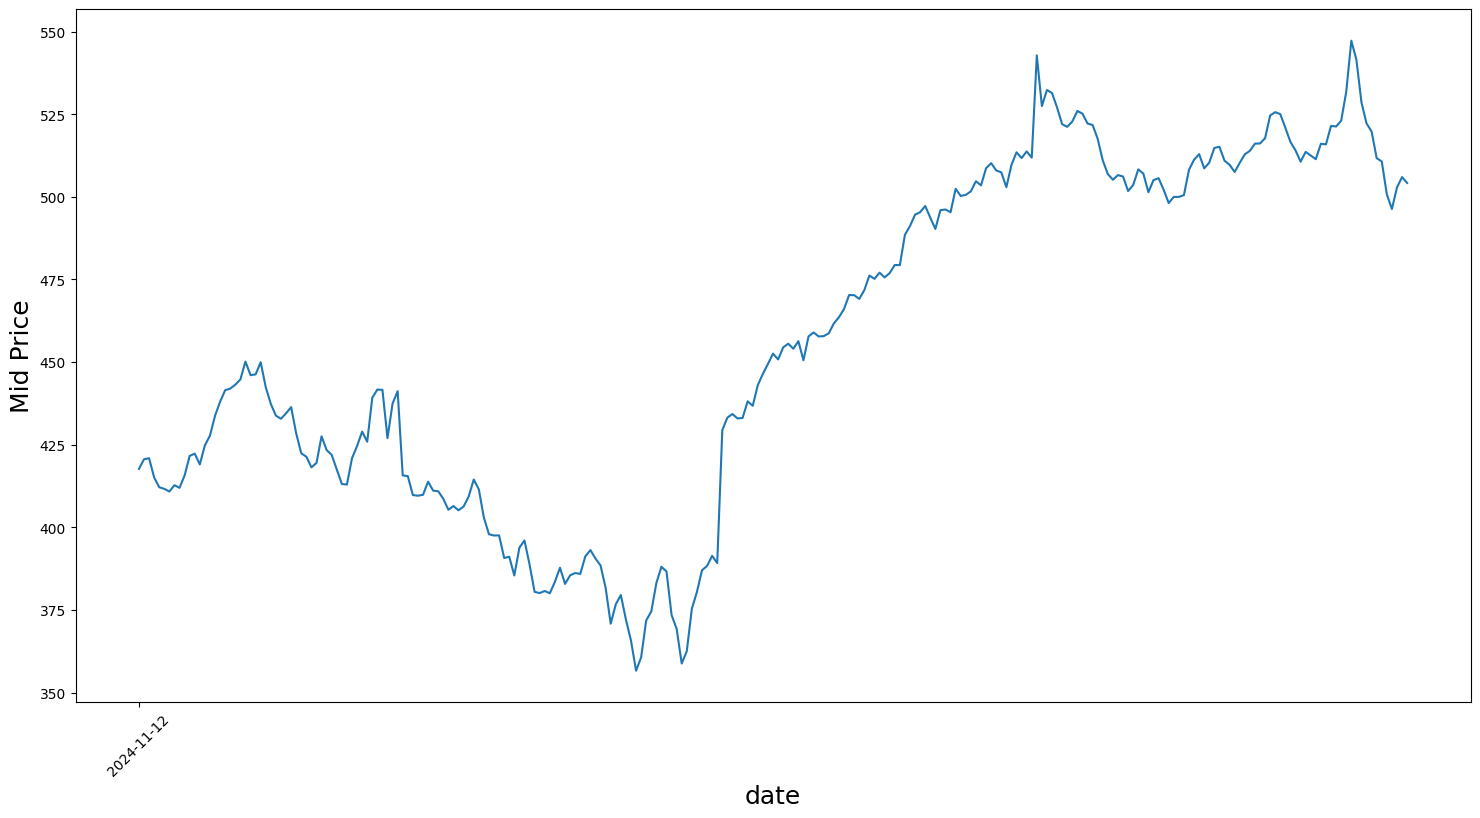

In [ ]:
plt.figure(figsize = (18,9))
plt.plot(range(df.shape[0]),(df['Low']+df['High'])/2.0)
plt.xticks(range(0,df.shape[0],500),df['date'].loc[::500],rotation=45)
plt.xlabel('date',fontsize=18)
plt.ylabel('Mid Price',fontsize=18)
plt.show()

In [ ]:
# First calculate the mid prices from the highest and lowest
high_prices = df.loc[:, 'High'].to_numpy()
low_prices = df.loc[:, 'Low'].to_numpy()
mid_prices = (high_prices + low_prices) / 2.0


In [ ]:
train_data = mid_prices[:11000]
test_data = mid_prices[11000:]

In [ ]:
scaler = MinMaxScaler()

# Correct split
split_ratio = 0.9
split_point = int(len(mid_prices) * split_ratio)

train_data = mid_prices[:split_point]
test_data = mid_prices[split_point:]


In [ ]:
smoothing_window_size = 2500

for di in range(0, len(train_data), smoothing_window_size):
    window = train_data[di:di+smoothing_window_size]

    # Toujours reshape
    window_reshaped = window.reshape(-1, 1)

    # Fit + transform
    scaled = scaler.fit_transform(window_reshaped)

    # Réassignation compatible
    train_data[di:di+smoothing_window_size] = scaled.reshape(window.shape)




In [ ]:
# Reshape both train and test data
train_data = train_data.reshape(-1)

# Normalize test data
if test_data.size == 0:
    print(" test_data is empty, skipping normalization.")
else:
    test_data = scaler.transform(test_data.reshape(-1, 1)).reshape(-1)


In [ ]:
# Now perform exponential moving average smoothing
# So the data will have a smoother curve than the original ragged data
print("train_data shape:", train_data.shape)
print("test_data shape:", test_data.shape)

EMA = 0.0
gamma = 0.1
n = train_data.shape[0]
for ti in range(n):
    EMA = gamma * train_data[ti] + (1 - gamma) * EMA
    train_data[ti] = EMA


# Used for visualization and test purposes
all_mid_data = np.concatenate([train_data,test_data],axis=0)


train_data shape: (225,)
test_data shape: (26,)


In [ ]:
window_size = 100
N = train_data.size
std_avg_predictions = []
std_avg_x = []
mse_errors = []

for pred_idx in range(window_size,N):

    if pred_idx >= N:
        date = dt.datetime.strptime(k, '%Y-%m-%d').date() + dt.timedelta(days=1)
    else:
        date = df.loc[pred_idx,'date']

    std_avg_predictions.append(np.mean(train_data[pred_idx-window_size:pred_idx]))
    mse_errors.append((std_avg_predictions[-1]-train_data[pred_idx])**2)
    std_avg_x.append(date)

print('MSE error for standard averaging: %.5f'%(0.5*np.mean(mse_errors)))


MSE error for standard averaging: 0.03959


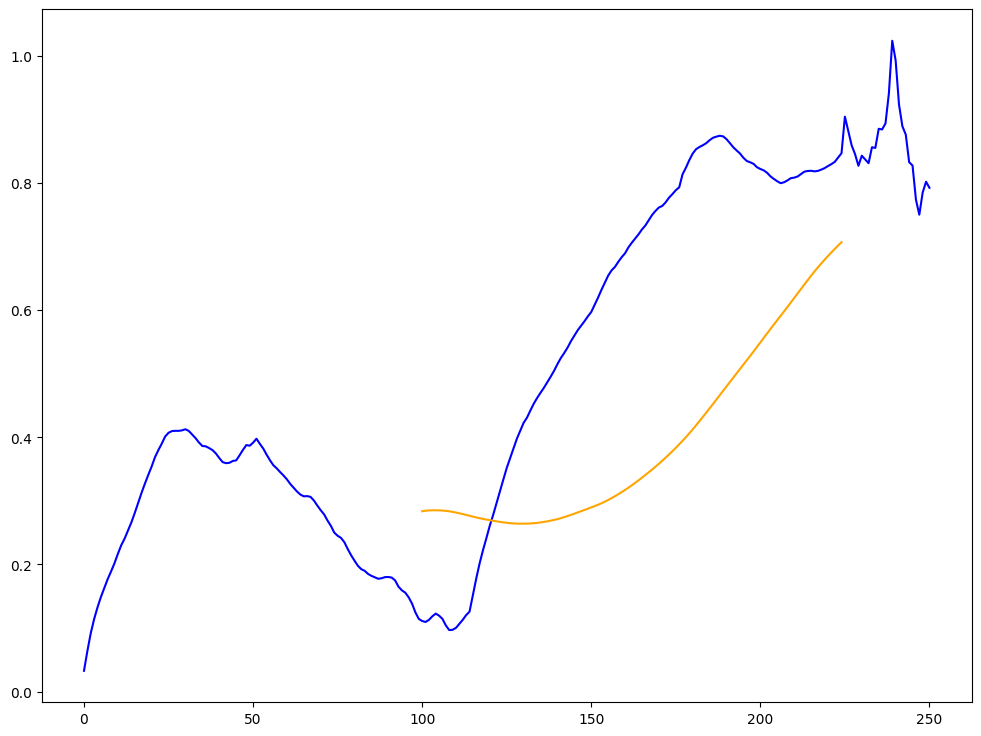

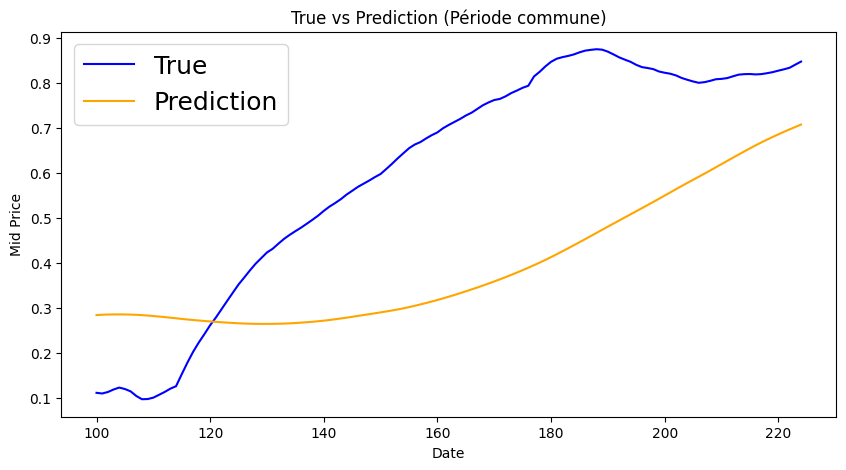

In [ ]:
# Au lieu de plotter tout
plt.figure(figsize=(12,9))
plt.plot(range(df.shape[0]), all_mid_data, color='b', label='True')
plt.plot(range(window_size, N), std_avg_predictions, color='orange', label='Prediction')

# COUPER POUR NE MONTRER QUE LA PÉRIODE COMMUNE
plt.figure(figsize=(10,5))

# Commencer à partir de window_size (où les prédictions commencent)
start_idx = window_size  # 100
end_idx = N  # ou len(all_mid_data)

# Plotter seulement la partie commune
plt.plot(range(start_idx, end_idx), all_mid_data[start_idx:end_idx], color='b', label='True')
plt.plot(range(start_idx, N), std_avg_predictions, color='orange', label='Prediction')

plt.xlabel('Date')
plt.ylabel('Mid Price')
plt.title('True vs Prediction (Période commune)')
plt.legend(fontsize=18)
plt.show()


🔹 TRAITEMENT DE AAPL

📐 Architecture du modèle:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_11                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,217 (379.75 KB)

 Trainable params: 97,217 (379.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Début de l'entraînement pour AAPL...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - loss: 0.2737 - mae: 0.2755 - val_loss: 0.1610 - val_mae: 0.0959
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - loss: 0.1554 - mae: 0.0896 - val_loss: 0.1467 - val_mae: 0.1131
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.1327 - mae: 0.0799 - val_loss: 0.1312 - val_mae: 0.1224
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.1131 - mae: 0.0695 - val_loss: 0.1065 - val_mae: 0.0961
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0966 - mae: 0.0627 - val_loss: 0.0910 - val_mae: 0.0899
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0831 - mae: 0.0620 - val_loss: 0.0817 - val_mae: 0.0995
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - loss: 0.0717 - mae: 0.0623 - val_loss: 0.0661 - val_mae: 0.0732
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0619 - mae: 0.0575 - val_loss: 0.0593 - val_mae: 0.0810
Epoch 9/50
16/16

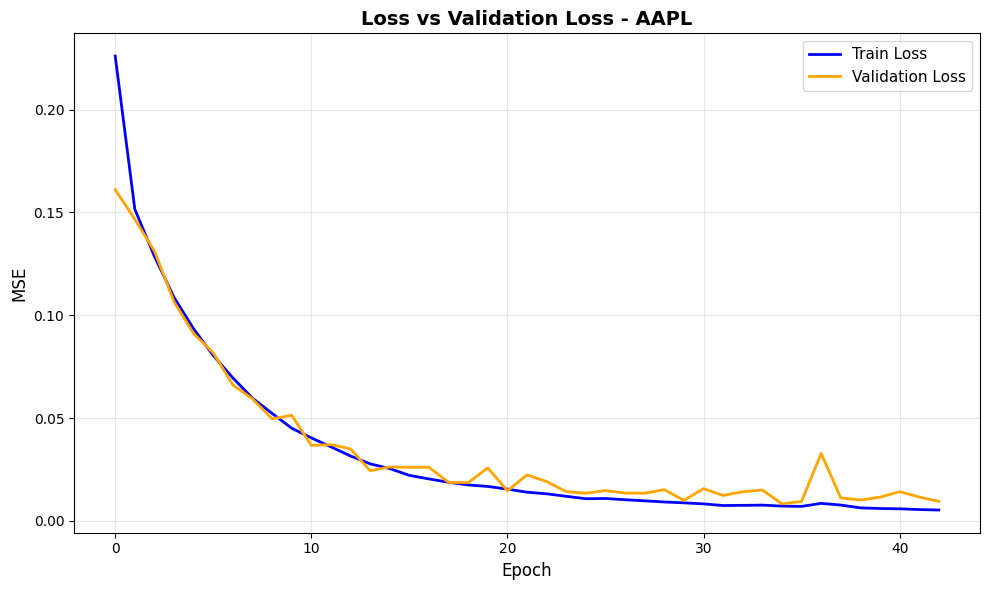

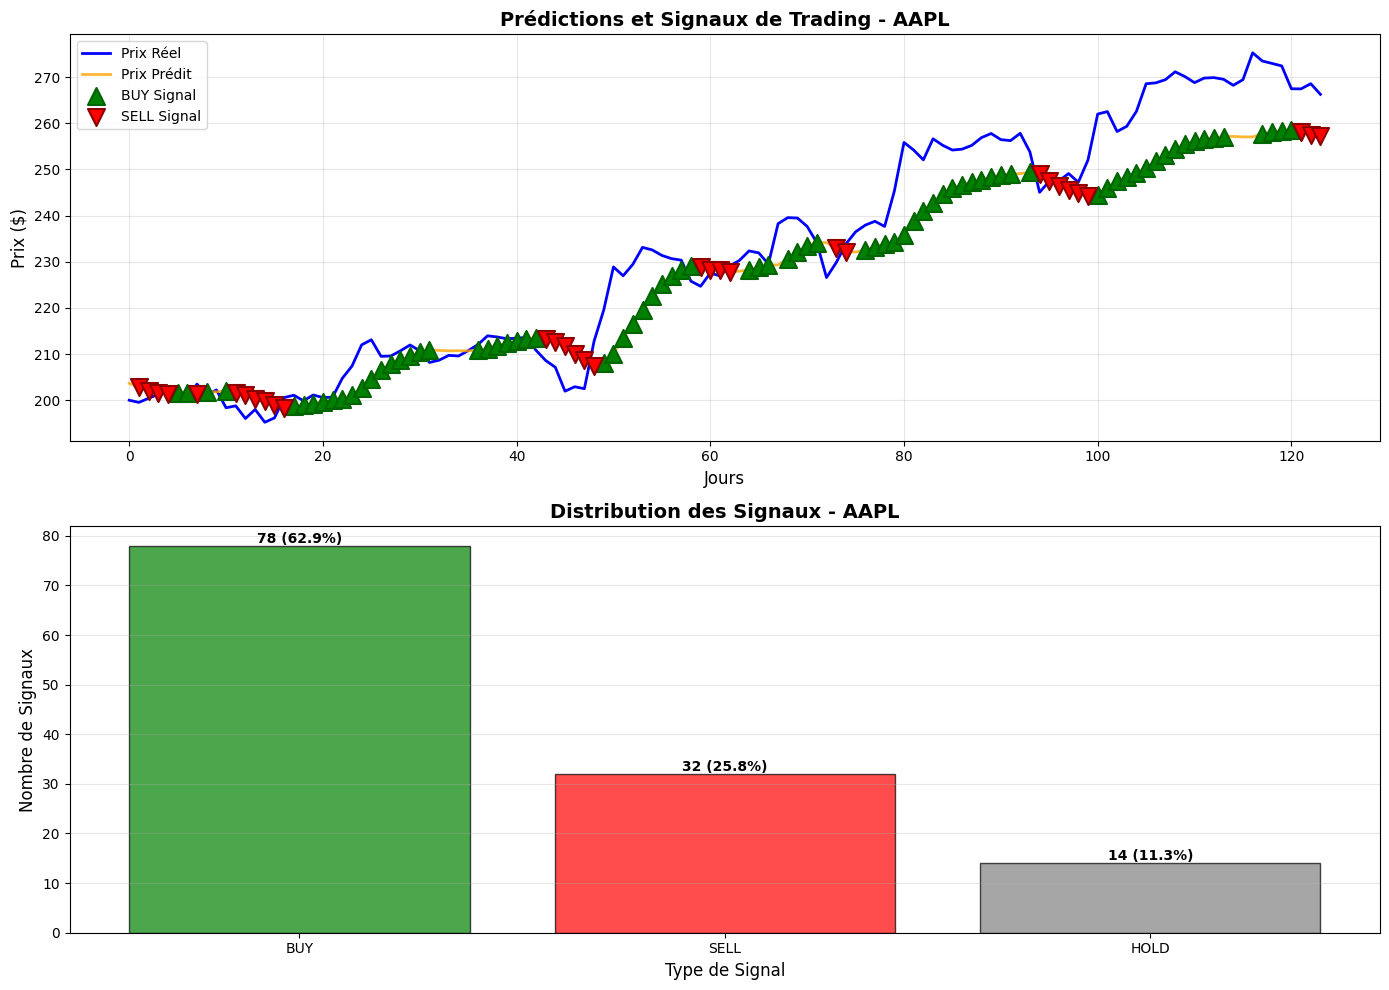

✅ Signaux sauvegardés: signals/signals_AAPL.csv

🔹 TRAITEMENT DE TSLA

📐 Architecture du modèle:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_12                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,217 (379.75 KB)

 Trainable params: 97,217 (379.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Début de l'entraînement pour TSLA...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - loss: 0.2226 - mae: 0.1915 - val_loss: 0.1780 - val_mae: 0.1469
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.1550 - mae: 0.0859 - val_loss: 0.1335 - val_mae: 0.0704
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.1304 - mae: 0.0753 - val_loss: 0.1127 - val_mae: 0.0580
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.1112 - mae: 0.0691 - val_loss: 0.0960 - val_mae: 0.0542
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0957 - mae: 0.0676 - val_loss: 0.0820 - val_mae: 0.0497
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0818 - mae: 0.0622 - val_loss: 0.0708 - val_mae: 0.0510
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0689 - mae: 0.0539 - val_loss: 0.0672 - val_mae: 0.0874
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0595 - mae: 0.0536 - val_loss: 0.0567 - val_mae: 0.0755
Epoch 9/50
16/16

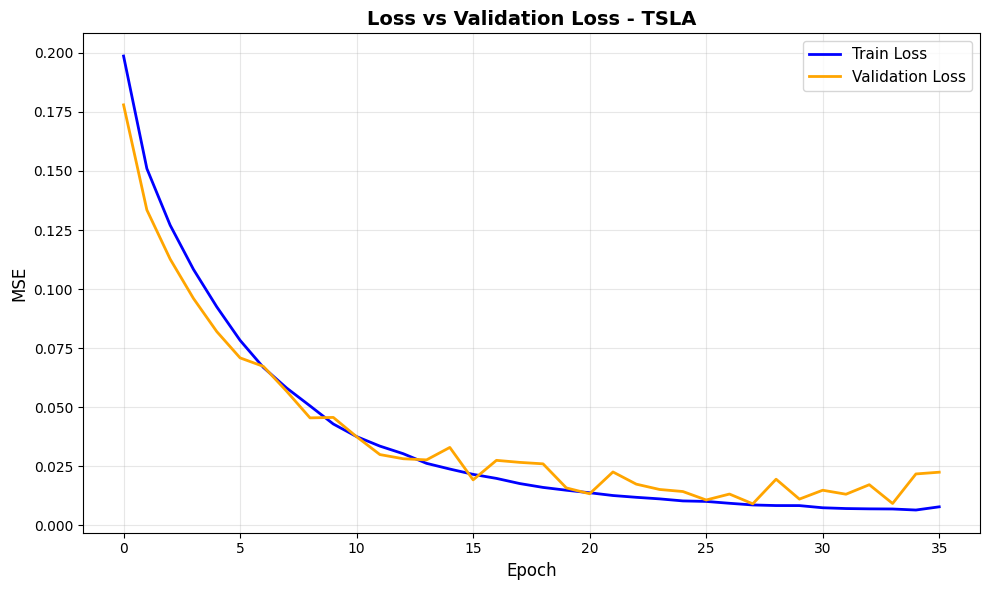

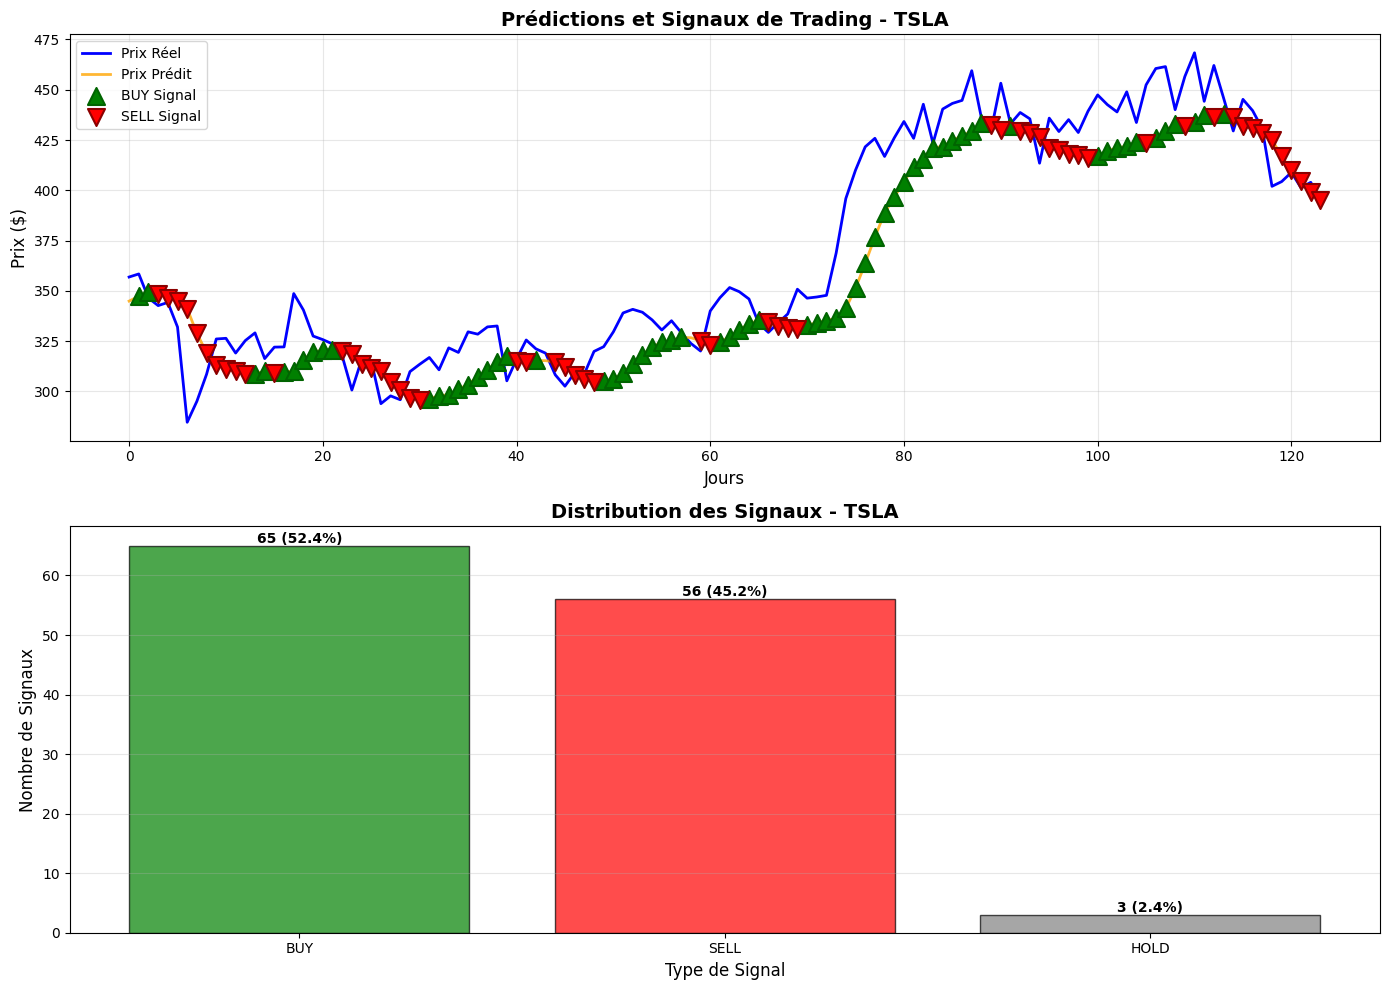

✅ Signaux sauvegardés: signals/signals_TSLA.csv

🔹 TRAITEMENT DE MSFT

📐 Architecture du modèle:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_13                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,217 (379.75 KB)

 Trainable params: 97,217 (379.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Début de l'entraînement pour MSFT...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - loss: 0.3201 - mae: 0.3581 - val_loss: 0.1649 - val_mae: 0.1179
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.1703 - mae: 0.1343 - val_loss: 0.2518 - val_mae: 0.3492
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.1344 - mae: 0.0867 - val_loss: 0.1754 - val_mae: 0.2544
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.1117 - mae: 0.0659 - val_loss: 0.1415 - val_mae: 0.2177
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - loss: 0.0954 - mae: 0.0636 - val_loss: 0.1226 - val_mae: 0.2064
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0823 - mae: 0.0651 - val_loss: 0.1046 - val_mae: 0.1904
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0696 - mae: 0.0572 - val_loss: 0.0924 - val_mae: 0.1843
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0605 - mae: 0.0602 - val_loss: 0.0876 - val_mae: 0.1943
Epoch 9/50
16/16

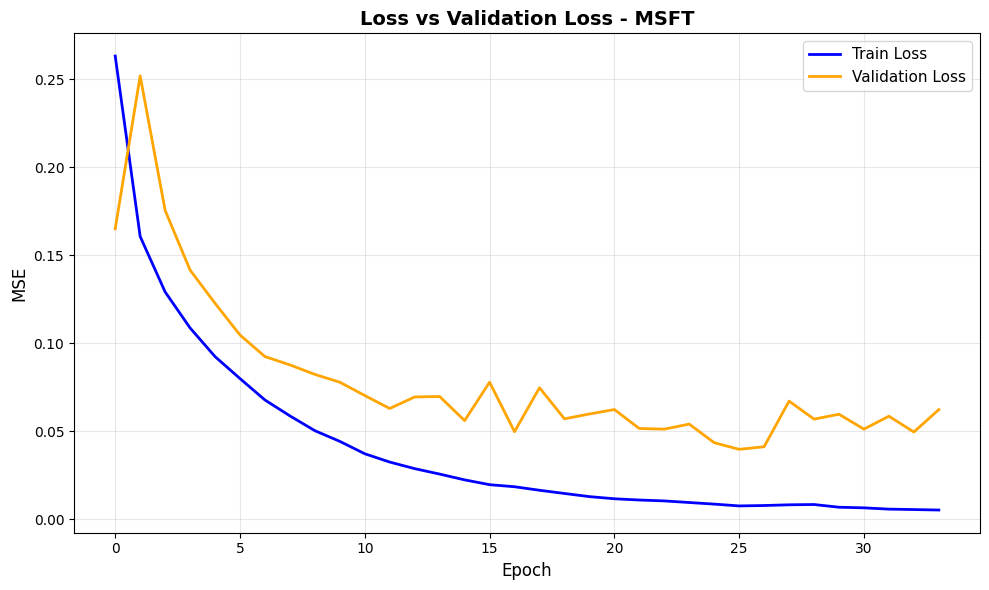

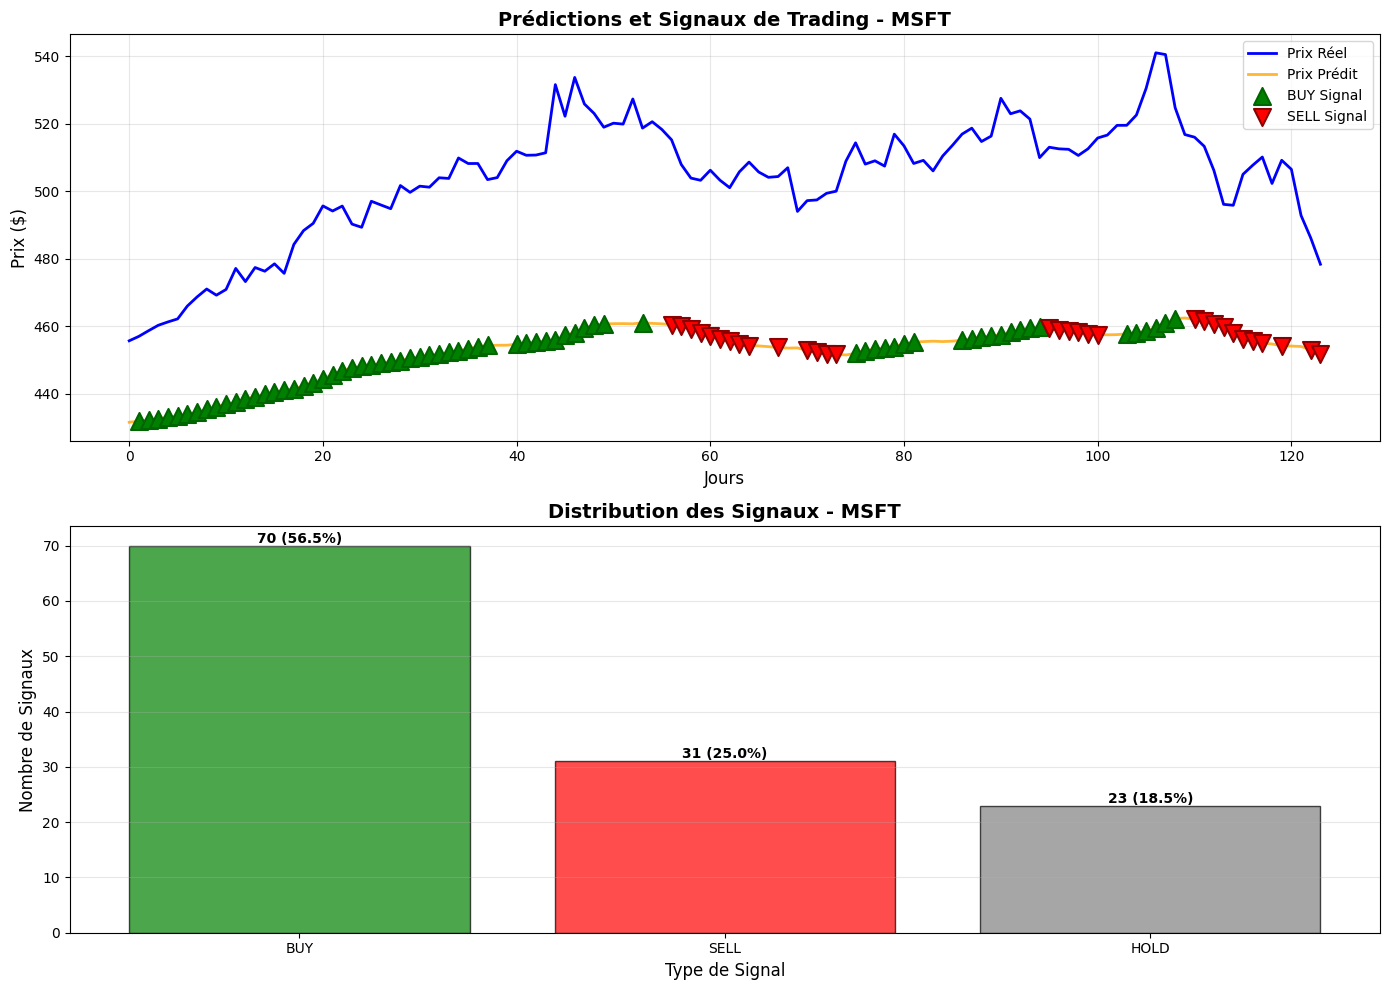

✅ Signaux sauvegardés: signals/signals_MSFT.csv

🔹 TRAITEMENT DE BTC-USD

📐 Architecture du modèle:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_14                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,217 (379.75 KB)

 Trainable params: 97,217 (379.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Début de l'entraînement pour BTC-USD...
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - loss: 0.2780 - mae: 0.2665 - val_loss: 0.1682 - val_mae: 0.1682
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 0.1404 - mae: 0.0849 - val_loss: 0.1172 - val_mae: 0.0843
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.1079 - mae: 0.0541 - val_loss: 0.0958 - val_mae: 0.0933
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0857 - mae: 0.0508 - val_loss: 0.0719 - val_mae: 0.0587
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - loss: 0.0669 - mae: 0.0432 - val_loss: 0.0616 - val_mae: 0.0844
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0541 - mae: 0.0453 - val_loss: 0.0472 - val_mae: 0.0632
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0430 - mae: 0.0438 - val_loss: 0.0450 - val_mae: 0.1003
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0348 - mae: 0.0401 - val_loss: 0.0339 - val_mae: 0.0768
Epoch 9/50
2

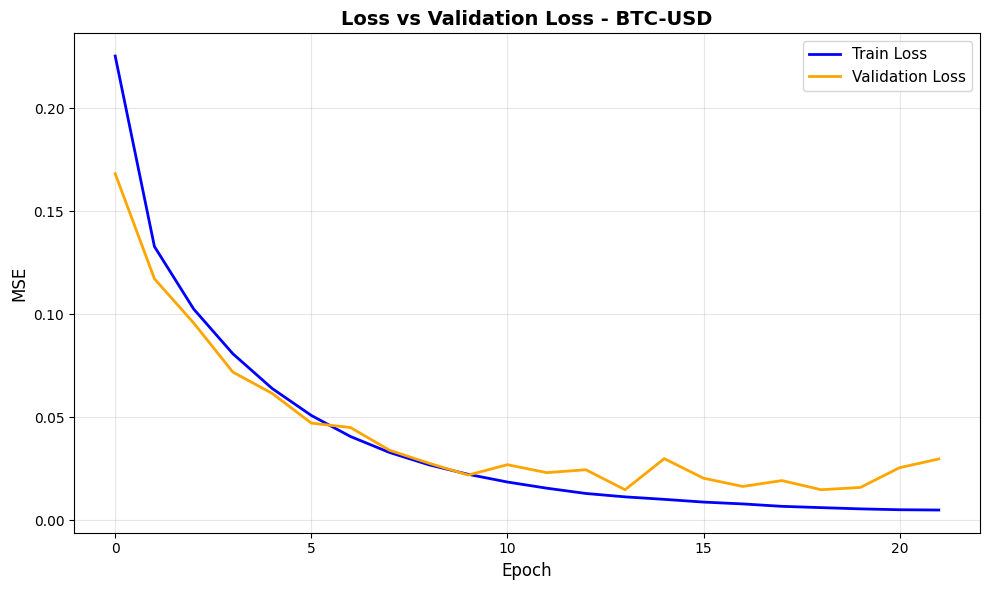

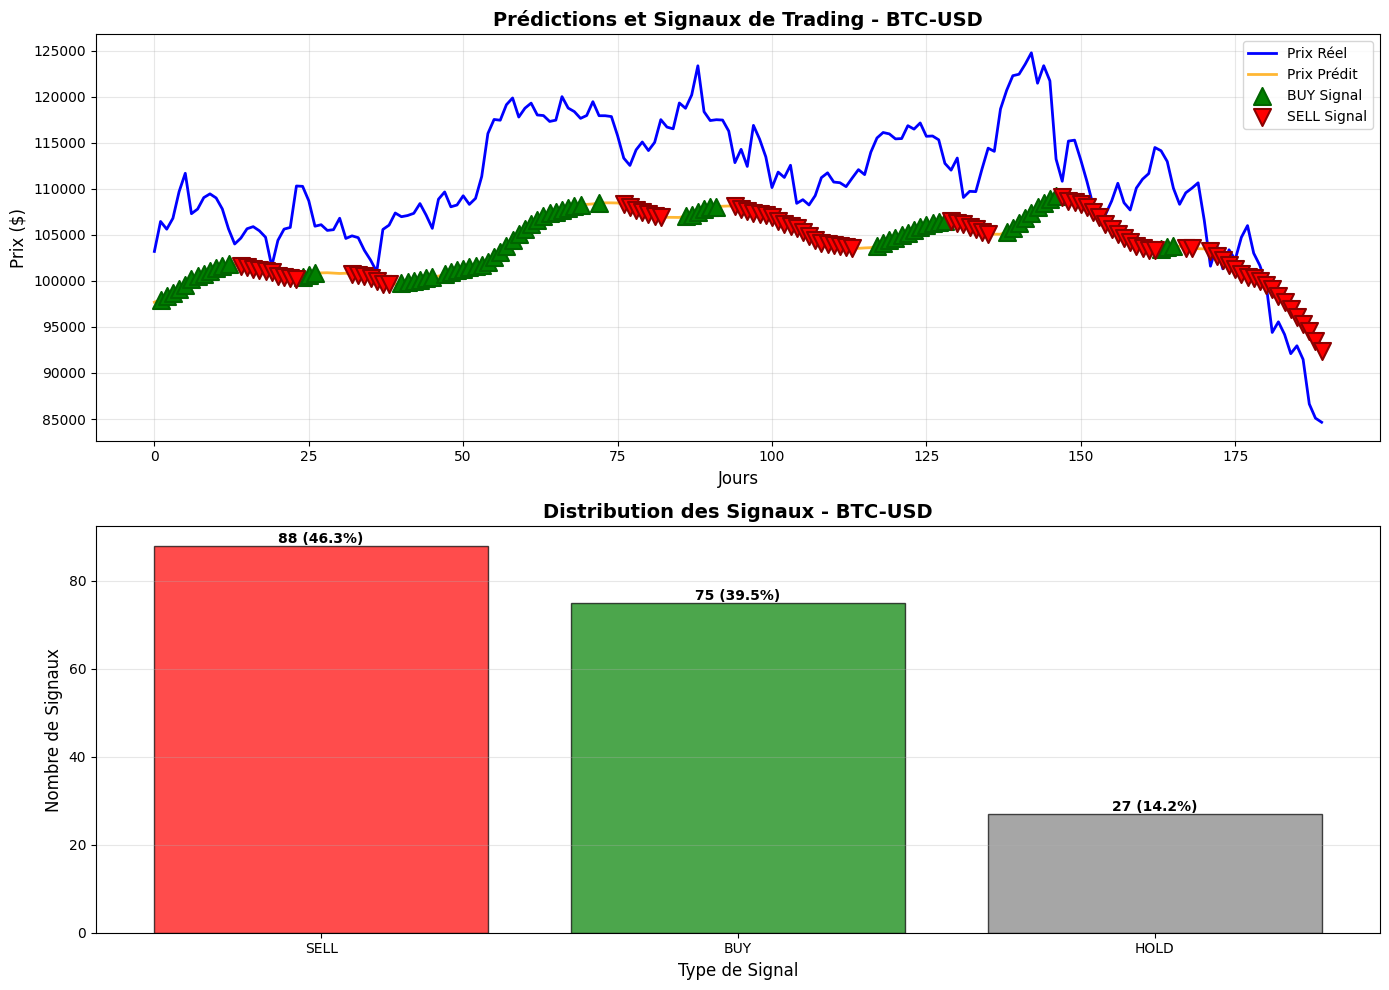

✅ Signaux sauvegardés: signals/signals_BTC-USD.csv

🔹 TRAITEMENT DE GOOGL

📐 Architecture du modèle:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_15                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_43 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_44 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,217 (379.75 KB)

 Trainable params: 97,217 (379.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Début de l'entraînement pour GOOGL...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - loss: 0.2420 - mae: 0.2489 - val_loss: 0.1622 - val_mae: 0.1082
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.1534 - mae: 0.0931 - val_loss: 0.1959 - val_mae: 0.2323
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.1244 - mae: 0.0571 - val_loss: 0.1519 - val_mae: 0.1800
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.1043 - mae: 0.0469 - val_loss: 0.1145 - val_mae: 0.1255
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - loss: 0.0882 - mae: 0.0481 - val_loss: 0.1028 - val_mae: 0.1399
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0739 - mae: 0.0429 - val_loss: 0.0854 - val_mae: 0.1269
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0619 - mae: 0.0379 - val_loss: 0.0747 - val_mae: 0.1277
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0528 - mae: 0.0403 - val_loss: 0.0580 - val_mae: 0.0971
Epoch 9/50
16/

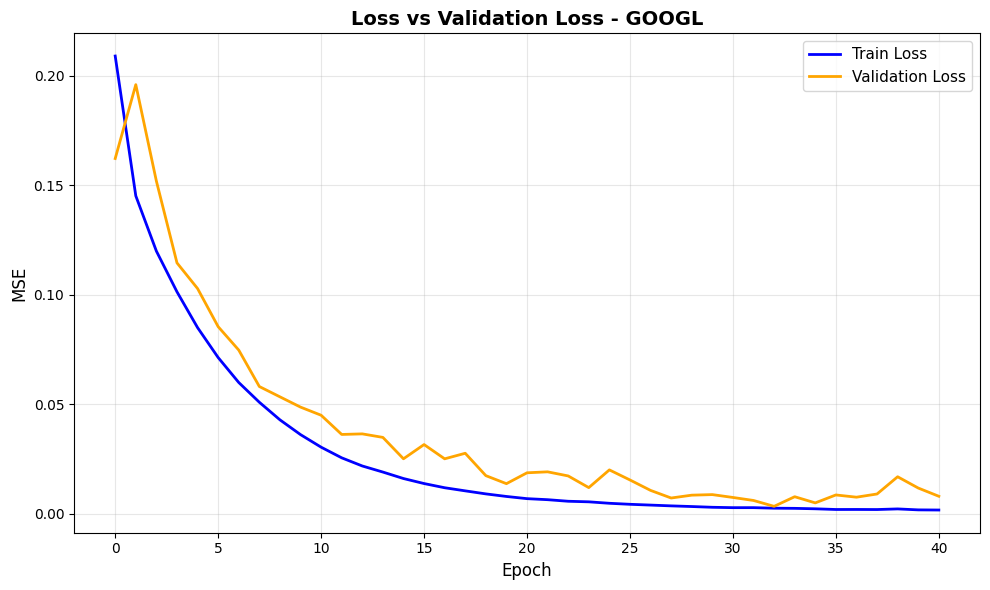

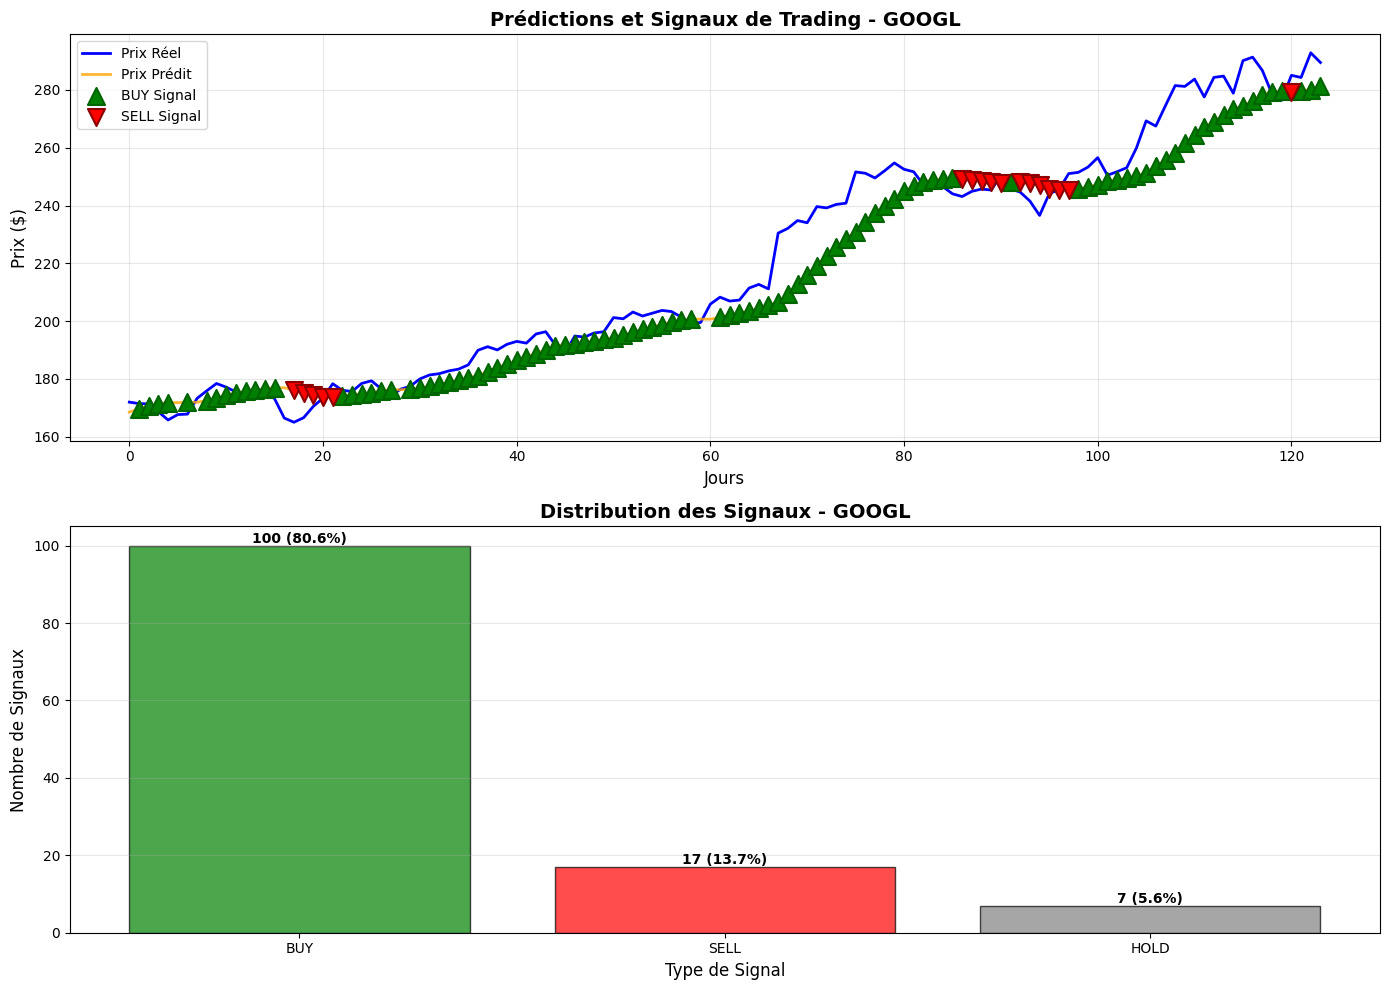

✅ Signaux sauvegardés: signals/signals_GOOGL.csv

🔹 TRAITEMENT DE NVDA

📐 Architecture du modèle:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_16                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_46 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,217 (379.75 KB)

 Trainable params: 97,217 (379.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Début de l'entraînement pour NVDA...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step - loss: 0.2785 - mae: 0.2791 - val_loss: 0.1489 - val_mae: 0.0344
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.1570 - mae: 0.1052 - val_loss: 0.1722 - val_mae: 0.2100
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.1283 - mae: 0.0689 - val_loss: 0.1299 - val_mae: 0.1451
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.1081 - mae: 0.0536 - val_loss: 0.1036 - val_mae: 0.1053
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0924 - mae: 0.0517 - val_loss: 0.0895 - val_mae: 0.1035
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - loss: 0.0793 - mae: 0.0503 - val_loss: 0.0808 - val_mae: 0.1169
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - loss: 0.0678 - mae: 0.0485 - val_loss: 0.0708 - val_mae: 0.1157
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0586 - mae: 0.0495 - val_loss: 0.0589 - val_mae: 0.0987
Epoch 9/50
16/1

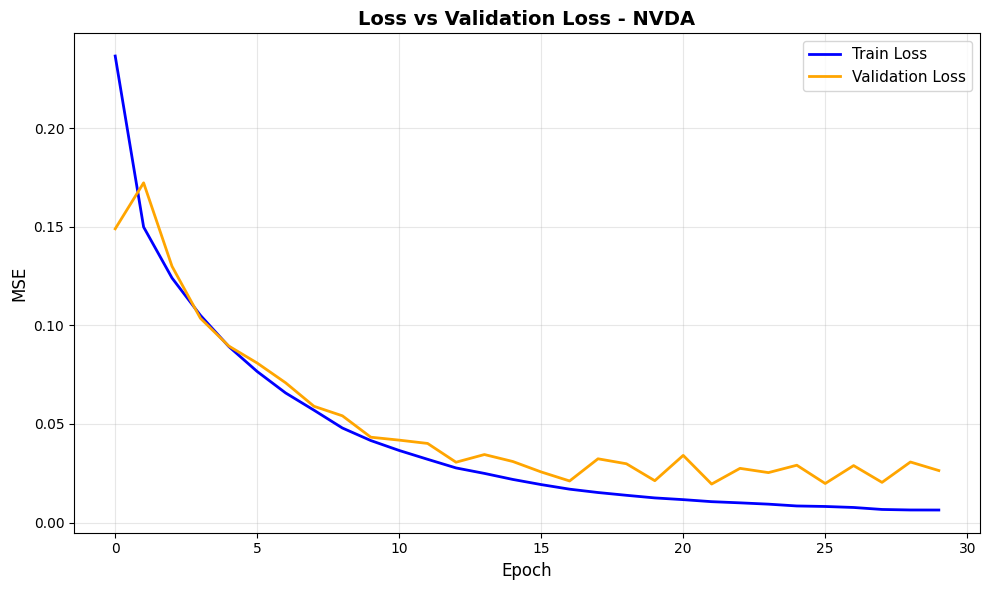

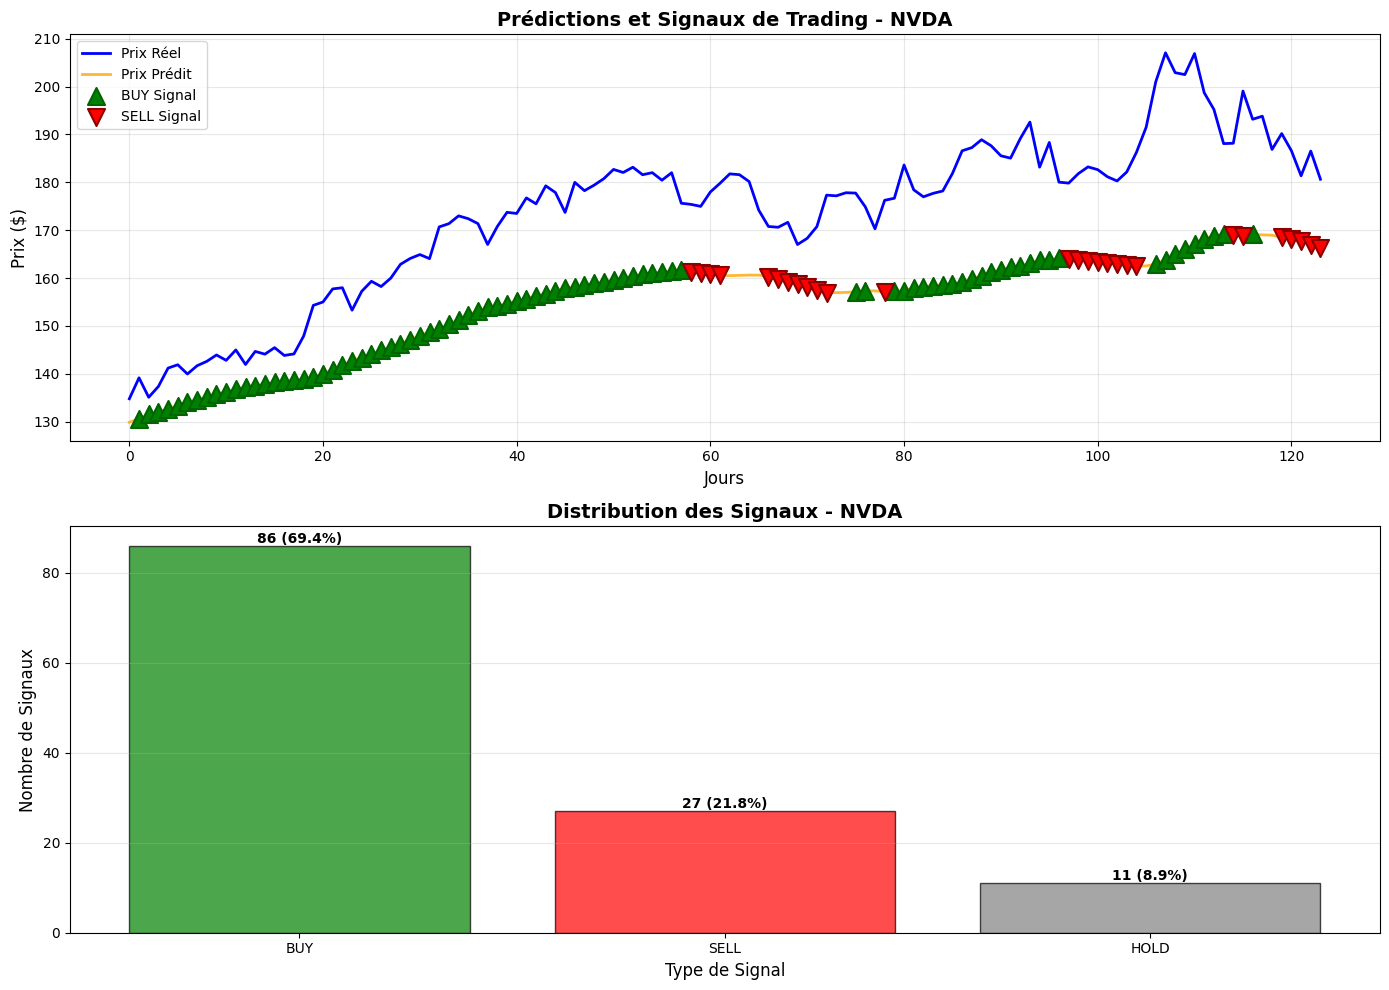

✅ Signaux sauvegardés: signals/signals_NVDA.csv

🔹 TRAITEMENT DE AMZN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



📐 Architecture du modèle:


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_17                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,217 (379.75 KB)

 Trainable params: 97,217 (379.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Début de l'entraînement pour AMZN...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - loss: 0.3735 - mae: 0.4218 - val_loss: 0.1885 - val_mae: 0.1942
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.1706 - mae: 0.1399 - val_loss: 0.2298 - val_mae: 0.3156
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.1458 - mae: 0.1187 - val_loss: 0.1298 - val_mae: 0.1349
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.1137 - mae: 0.0727 - val_loss: 0.1006 - val_mae: 0.0720
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - loss: 0.0974 - mae: 0.0648 - val_loss: 0.0881 - val_mae: 0.0797
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0845 - mae: 0.0660 - val_loss: 0.0779 - val_mae: 0.0880
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0720 - mae: 0.0633 - val_loss: 0.0647 - val_mae: 0.0688
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0613 - mae: 0.0565 - val_loss: 0.0591 - val_mae: 0.0860
Epoch 9/50
16/1

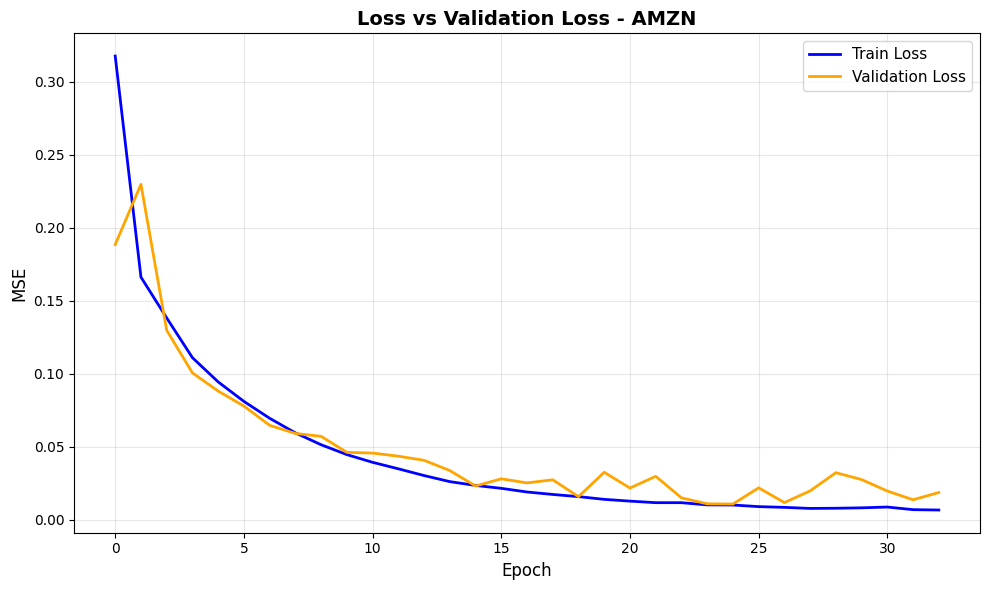

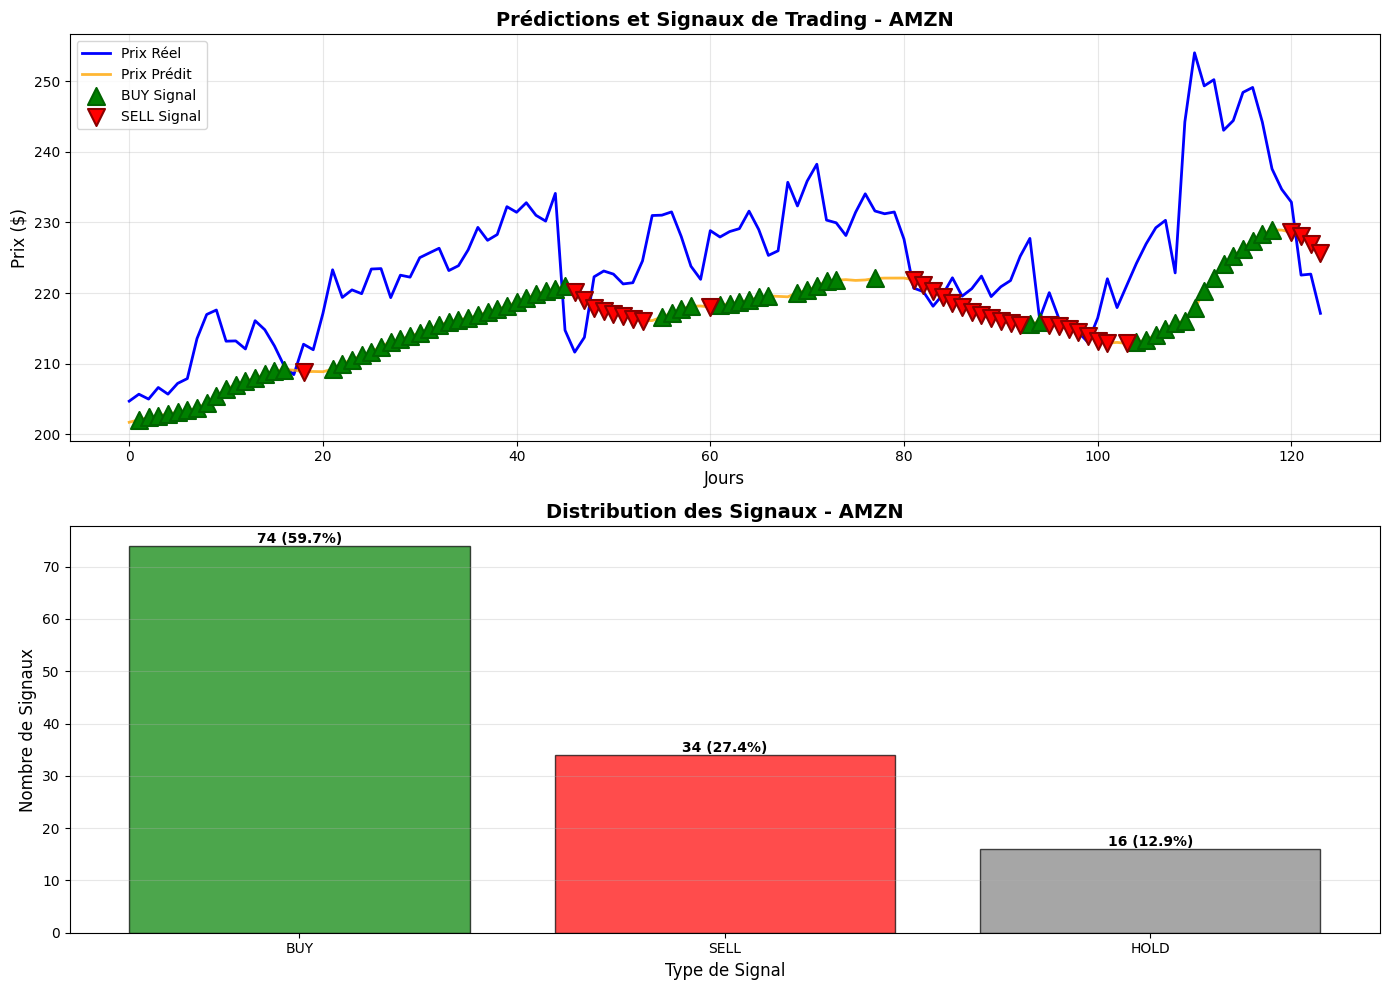

✅ Signaux sauvegardés: signals/signals_AMZN.csv

🔹 TRAITEMENT DE META

📐 Architecture du modèle:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_18                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,217 (379.75 KB)

 Trainable params: 97,217 (379.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Début de l'entraînement pour META...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - loss: 0.2873 - mae: 0.2948 - val_loss: 0.1624 - val_mae: 0.1041
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.1566 - mae: 0.0839 - val_loss: 0.1524 - val_mae: 0.1374
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.1359 - mae: 0.0837 - val_loss: 0.1448 - val_mae: 0.1688
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.1147 - mae: 0.0619 - val_loss: 0.1111 - val_mae: 0.1108
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.1000 - mae: 0.0570 - val_loss: 0.0923 - val_mae: 0.0871
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - loss: 0.0851 - mae: 0.0509 - val_loss: 0.0778 - val_mae: 0.0681
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.0750 - mae: 0.0551 - val_loss: 0.0705 - val_mae: 0.0846
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0656 - mae: 0.0541 - val_loss: 0.0622 - val_mae: 0.0849
Epoch 9/50
16/16

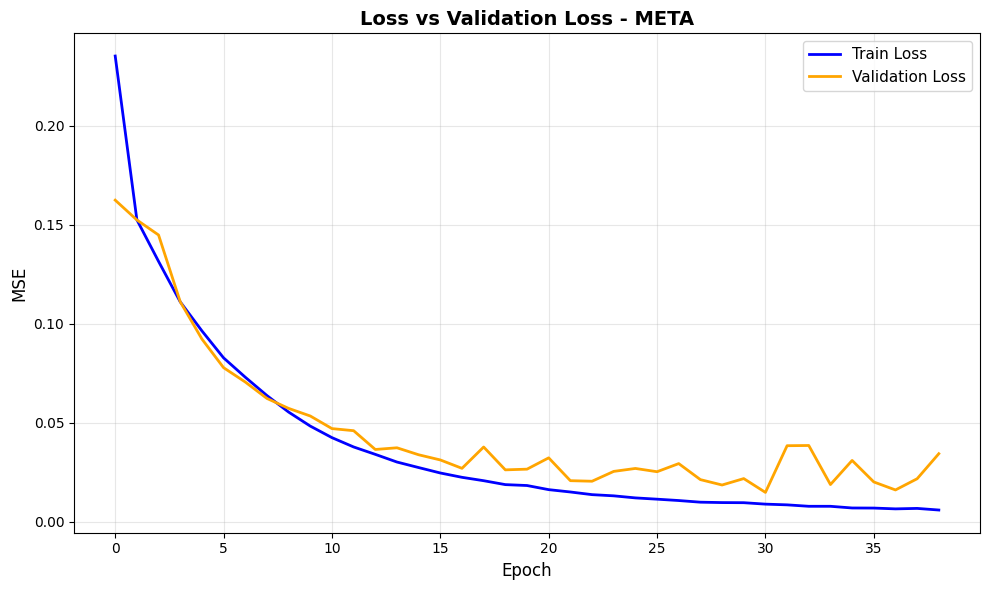

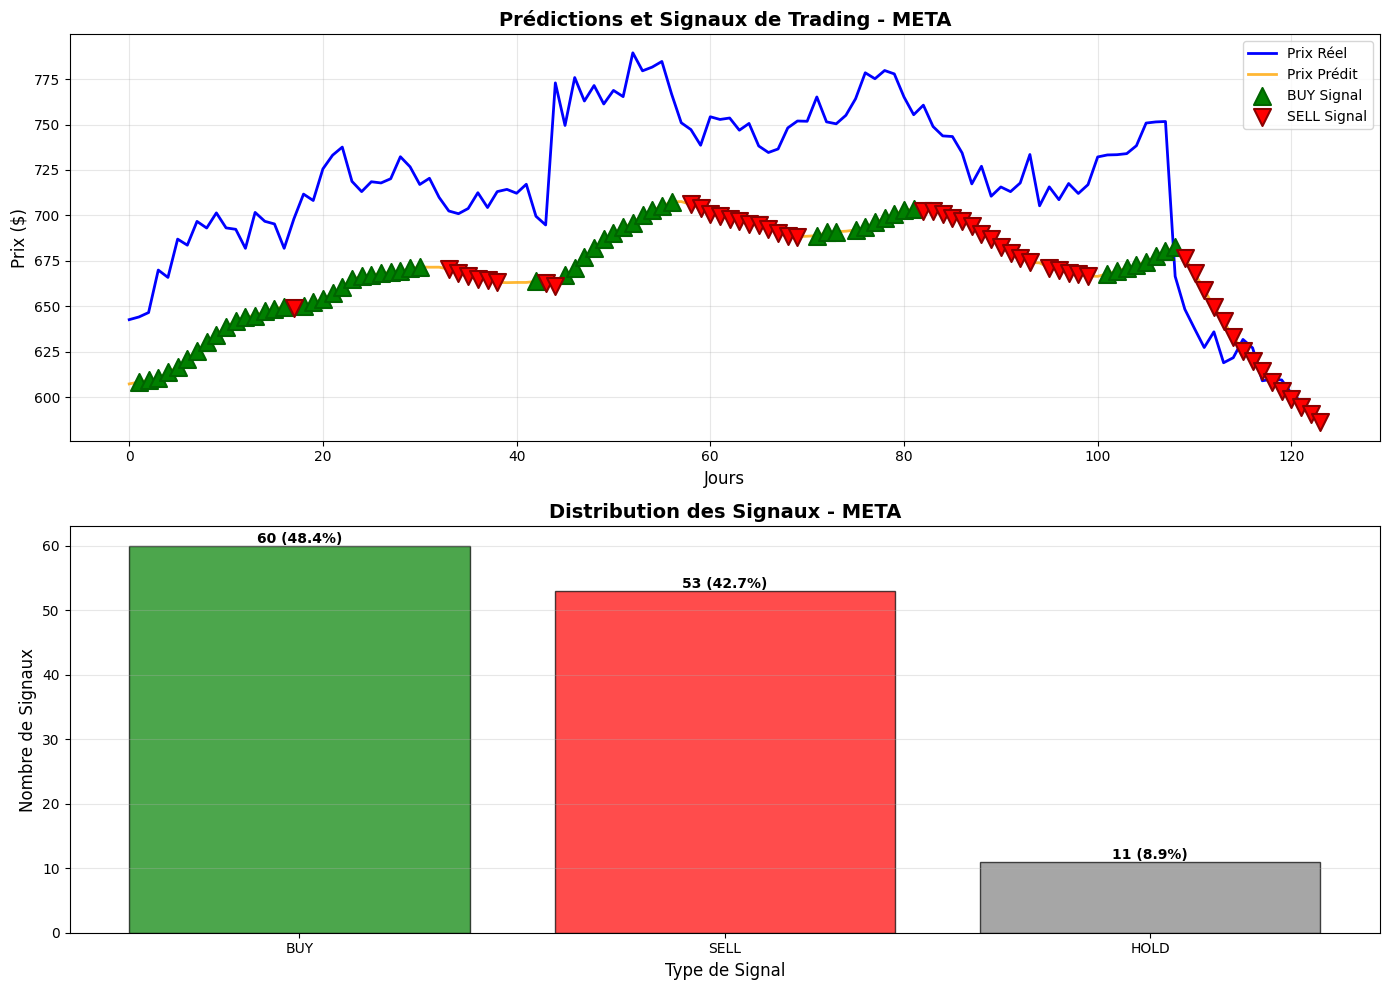

✅ Signaux sauvegardés: signals/signals_META.csv

📊 RÉSULTATS GLOBAUX

📋 Tableau récapitulatif:
 Symbol         MAE        RMSE  Epochs_Used  BUY_Signals  SELL_Signals  HOLD_Signals  Signal_Accuracy_%
   AAPL    6.559281    8.447058           43           78            32            14          42.276423
   TSLA   15.840254   20.098264           36           65            56             3          48.780488
   MSFT   51.042530   52.267092           34           70            31            23          45.528455
BTC-USD 7420.132730 8315.599417           22           75            88            27          44.444444
  GOOGL    6.788690    8.950412           41          100            17             7          49.593496
   NVDA   18.148266   19.640362           30           86            27            11          50.406504
   AMZN    8.884292   10.790091           33           74            34            16          46.341463
   META   50.650930   55.309508           39           60        

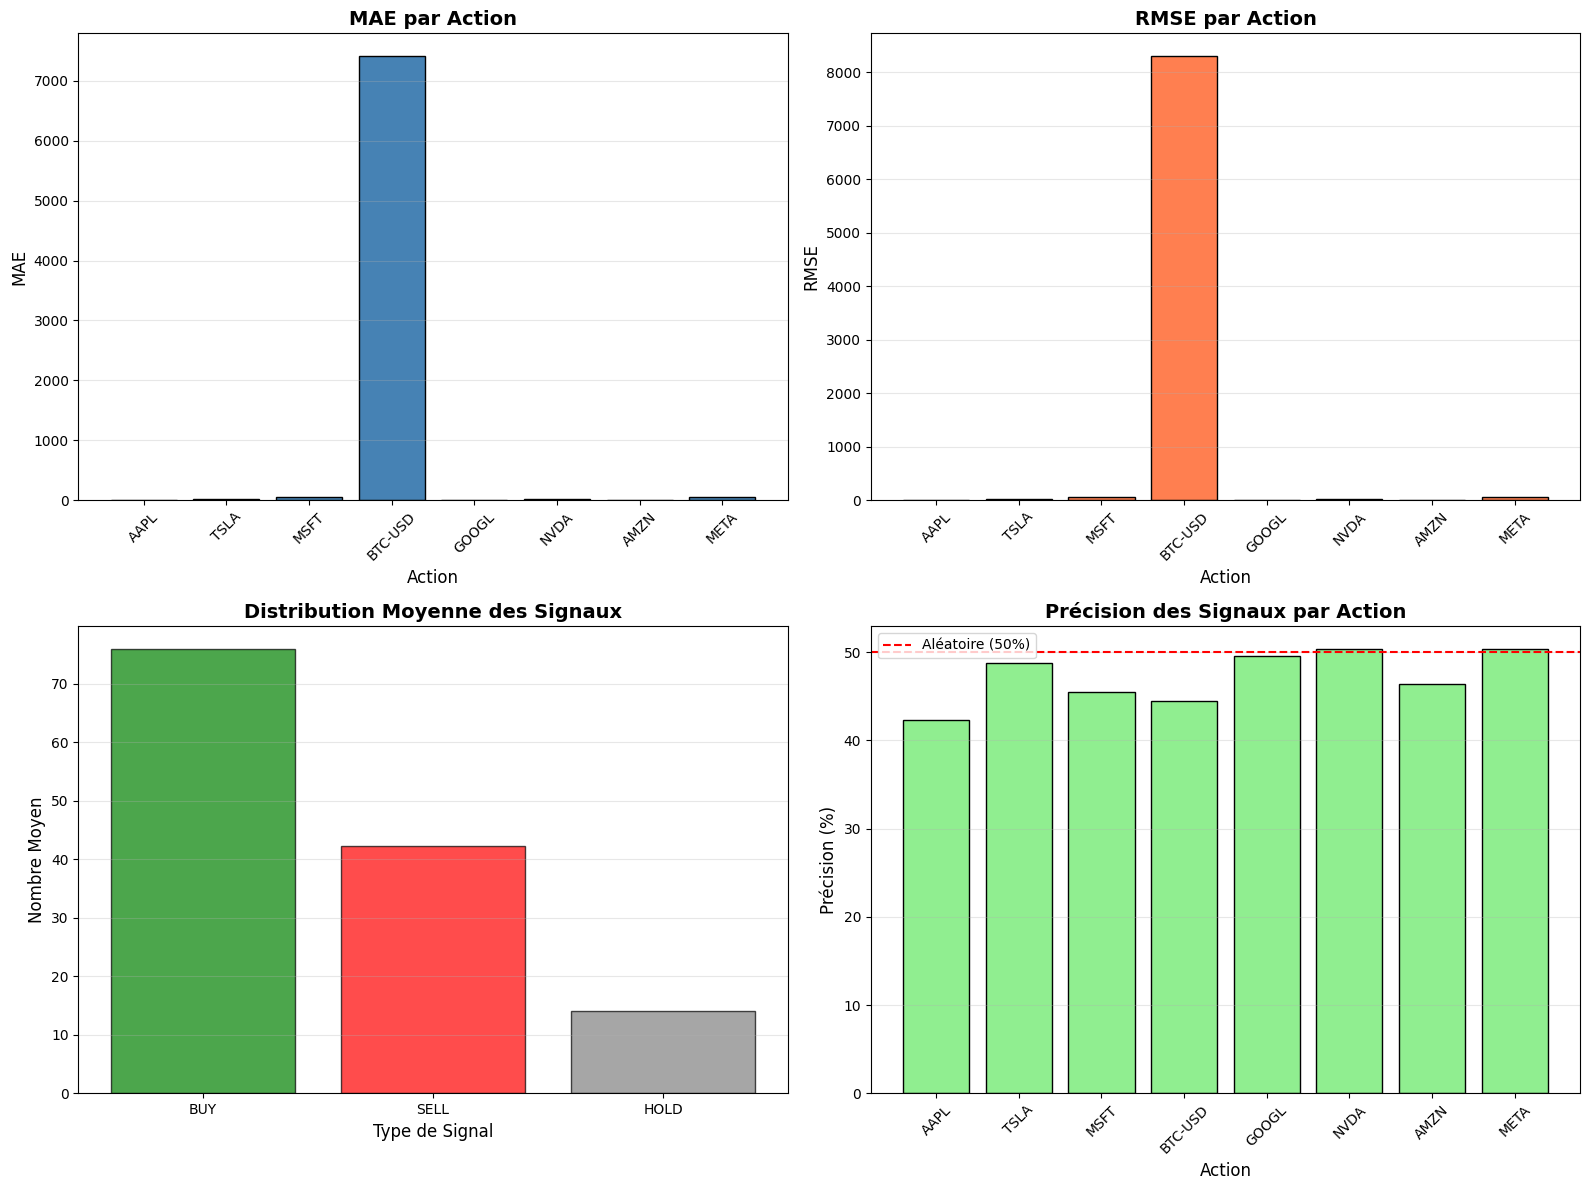


✅ ENTRAÎNEMENT TERMINÉ

📁 Fichiers générés:
   - Modèles: models/lstm_*.keras
   - Métriques: metrics/model_metrics.csv
   - Graphiques: plots/*.png
   - Signaux: signals/signals_*.csv

🎯 Précision moyenne des signaux: 47.22%
📊 Meilleure action (MAE): AAPL
📊 Action la plus volatile: BTC-USD

✅ Tous les résultats ont été sauvegardés avec succès!


In [ ]:


# ------------------------------------------
# 1. IMPORTS
# ------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------
# 2. FUNCTIONS
# ------------------------------------------

def create_sequences(data, seq_len=60):
    """Crée des séquences pour l'entraînement LSTM"""
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])
    return np.array(X), np.array(y)


def build_model(input_shape):
    """Architecture Bidirectional LSTM multi-couches"""
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.2),
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="mse",
        metrics=["mae"]
    )
    return model


def plot_loss(history, symbol, save_path="plots"):
    """Plot Train Loss vs Validation Loss"""
    plt.figure(figsize=(10, 6))
    plt.plot(history.history["loss"], label="Train Loss", linewidth=2, color='blue')
    plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2, color='orange')
    plt.title(f"Loss vs Validation Loss - {symbol}", fontsize=14, fontweight='bold')
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("MSE", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Sauvegarder
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(f"{save_path}/loss_{symbol}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_prediction_with_signals(real, pred, signals, symbol, save_path="plots"):
    """
    Plot des prédictions avec signaux BUY/SELL/HOLD
    Affiche uniquement la période commune (où les deux courbes existent)
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # ===== GRAPHIQUE 1: Prix Réels vs Prédits avec Signaux =====
    ax1.plot(real, label="Prix Réel", color='blue', linewidth=2)
    ax1.plot(pred, label="Prix Prédit", color='orange', linewidth=2, alpha=0.8)

    # Ajouter les marqueurs de signaux
    buy_indices = [i for i, s in enumerate(signals) if s == 'BUY']
    sell_indices = [i for i, s in enumerate(signals) if s == 'SELL']

    if buy_indices:
        ax1.scatter(buy_indices, pred[buy_indices],
                   color='green', marker='^', s=150,
                   label='BUY Signal', zorder=5, edgecolors='darkgreen', linewidths=1.5)
    if sell_indices:
        ax1.scatter(sell_indices, pred[sell_indices],
                   color='red', marker='v', s=150,
                   label='SELL Signal', zorder=5, edgecolors='darkred', linewidths=1.5)

    ax1.set_title(f"Prédictions et Signaux de Trading - {symbol}",
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel("Jours", fontsize=12)
    ax1.set_ylabel("Prix ($)", fontsize=12)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.3)

    # ===== GRAPHIQUE 2: Distribution des Signaux =====
    signal_counts = pd.Series(signals).value_counts()
    colors_map = {'BUY': 'green', 'SELL': 'red', 'HOLD': 'gray'}
    colors = [colors_map.get(s, 'gray') for s in signal_counts.index]

    bars = ax2.bar(signal_counts.index, signal_counts.values, color=colors, alpha=0.7, edgecolor='black')

    ax2.set_title(f"Distribution des Signaux - {symbol}", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Type de Signal", fontsize=12)
    ax2.set_ylabel("Nombre de Signaux", fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')

    # Ajouter les valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)} ({height/len(signals)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

    plt.tight_layout()

    # Sauvegarder
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(f"{save_path}/prediction_signals_{symbol}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def generate_trading_signals(predictions, threshold=0.02):
    """
    Génère des signaux BUY/SELL/HOLD basés sur les variations prédites

    Args:
        predictions: Array des prix prédits
        threshold: Seuil de variation (défaut 2%)

    Returns:
        signals: Liste des signaux
    """
    signals = []

    for i in range(1, len(predictions)):
        # Calculer la variation en pourcentage
        price_change = (predictions[i] - predictions[i-1]) / predictions[i-1]

        if price_change > threshold:
            signals.append('BUY')
        elif price_change < -threshold:
            signals.append('SELL')
        else:
            signals.append('HOLD')

    # Premier signal = HOLD
    signals.insert(0, 'HOLD')

    return signals


def calculate_signal_accuracy(signals, real_prices, threshold=0.02):
    """
    Calcule la précision des signaux générés
    """
    correct = 0

    for i in range(1, len(real_prices)):
        actual_change = (real_prices[i] - real_prices[i-1]) / real_prices[i-1]

        if signals[i] == 'BUY' and actual_change > 0:
            correct += 1
        elif signals[i] == 'SELL' and actual_change < 0:
            correct += 1
        elif signals[i] == 'HOLD' and abs(actual_change) < threshold:
            correct += 1

    accuracy = (correct / (len(signals) - 1)) * 100
    return accuracy


# ------------------------------------------
# 3. CONFIGURATION
# ------------------------------------------
EPOCHS = 50
BATCH_SIZE = 32
SEQ_LEN = 60
SIGNAL_THRESHOLD = 0.0005  # 2% de variation pour générer un signal

# Créer les dossiers de sortie
os.makedirs("models", exist_ok=True)
os.makedirs("metrics", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("signals", exist_ok=True)

# ------------------------------------------
# 4. CHARGER LES DONNÉES
# ------------------------------------------
df_all = pd.read_csv("ALL_FEATURES.csv")

results = []
all_signals_data = []

# ------------------------------------------
# 5. ENTRAÎNEMENT PAR ACTION
# ------------------------------------------

for symbol in df_all["symbol"].unique():

    print("\n" + "="*60)
    print(f"🔹 TRAITEMENT DE {symbol}")
    print("="*60)

    prices = df_all[df_all["symbol"] == symbol]["Close"].dropna().values

    if len(prices) < 300:
        print("⚠️ Pas assez de données, action ignorée")
        continue

    # --------------------
    # Normalisation
    # --------------------
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(prices.reshape(-1, 1))

    # --------------------
    # Création des séquences
    # --------------------
    X, y = create_sequences(scaled, SEQ_LEN)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    split = int(0.8 * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    # --------------------
    # Construction du modèle
    # --------------------
    model = build_model((SEQ_LEN, 1))

    print(f"\n📐 Architecture du modèle:")
    model.summary()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    # --------------------
    # Entraînement
    # --------------------
    print(f"\n🚀 Début de l'entraînement pour {symbol}...")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    # --------------------
    # Prédictions
    # --------------------
    val_pred_scaled = model.predict(X_val)
    val_pred = scaler.inverse_transform(val_pred_scaled)
    val_real = scaler.inverse_transform(y_val)

    # --------------------
    # Métriques de performance
    # --------------------
    mae = mean_absolute_error(val_real, val_pred)
    rmse = np.sqrt(mean_squared_error(val_real, val_pred))

    print(f"\n📊 MÉTRIQUES DE PERFORMANCE:")
    print(f"   MAE:  {mae:.4f}")
    print(f"   RMSE: {rmse:.4f}")

    # --------------------
    # Génération des signaux BUY/SELL/HOLD
    # --------------------
    print(f"\n💹 Génération des signaux de trading...")

    signals = generate_trading_signals(val_pred.flatten(), threshold=SIGNAL_THRESHOLD)
    signal_accuracy = calculate_signal_accuracy(signals, val_real.flatten(), threshold=SIGNAL_THRESHOLD)

    buy_count = signals.count('BUY')
    sell_count = signals.count('SELL')
    hold_count = signals.count('HOLD')
    total_signals = len(signals)

    print(f"\n📈 SIGNAUX DE TRADING:")
    print(f"   🟢 BUY:  {buy_count:4d} ({buy_count/total_signals*100:5.1f}%)")
    print(f"   🔴 SELL: {sell_count:4d} ({sell_count/total_signals*100:5.1f}%)")
    print(f"   ⚪ HOLD: {hold_count:4d} ({hold_count/total_signals*100:5.1f}%)")
    print(f"   🎯 Précision: {signal_accuracy:.2f}%")

    # --------------------
    # Sauvegarder le modèle et le scaler
    # --------------------
    model.save(f"models/lstm_{symbol}.keras")
    joblib.dump(scaler, f"models/scaler_{symbol}.save")
    print(f"\n✅ Modèle sauvegardé: models/lstm_{symbol}.keras")

    # --------------------
    # Visualisations
    # --------------------
    print(f"\n📊 Génération des graphiques...")

    # 1. Loss vs Validation Loss
    plot_loss(history, symbol)

    # 2. Prédictions avec signaux (afficher les 200 derniers points)
    display_range = min(200, len(val_real))
    plot_prediction_with_signals(
        val_real[-display_range:].flatten(),
        val_pred[-display_range:].flatten(),
        signals[-display_range:],
        symbol
    )

    # --------------------
    # Sauvegarder les signaux dans un CSV
    # --------------------
    signals_df = pd.DataFrame({
        'Symbol': symbol,
        'Day': range(len(val_real)),
        'Real_Price': val_real.flatten(),
        'Predicted_Price': val_pred.flatten(),
        'Signal': signals,
        'Price_Change_%': pd.Series(val_pred.flatten()).pct_change() * 100
    })

    signals_df.to_csv(f"signals/signals_{symbol}.csv", index=False)
    print(f"✅ Signaux sauvegardés: signals/signals_{symbol}.csv")

    # --------------------
    # Stocker les résultats globaux
    # --------------------
    results.append({
        "Symbol": symbol,
        "MAE": mae,
        "RMSE": rmse,
        "Epochs_Used": len(history.history["loss"]),
        "BUY_Signals": buy_count,
        "SELL_Signals": sell_count,
        "HOLD_Signals": hold_count,
        "Signal_Accuracy_%": signal_accuracy
    })

    all_signals_data.append(signals_df)

# ------------------------------------------
# 6. SAUVEGARDER LES MÉTRIQUES GLOBALES
# ------------------------------------------
print("\n" + "="*60)
print("📊 RÉSULTATS GLOBAUX")
print("="*60)

metrics_df = pd.DataFrame(results)
metrics_df.to_csv("metrics/model_metrics.csv", index=False)

print("\n📋 Tableau récapitulatif:")
print(metrics_df.to_string(index=False))

# ------------------------------------------
# 7. CRÉER UN RÉSUMÉ VISUEL GLOBAL
# ------------------------------------------
print("\n📊 Création du graphique de comparaison globale...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1: MAE par action
ax1 = axes[0, 0]
ax1.bar(metrics_df['Symbol'], metrics_df['MAE'], color='steelblue', edgecolor='black')
ax1.set_title('MAE par Action', fontsize=14, fontweight='bold')
ax1.set_xlabel('Action', fontsize=12)
ax1.set_ylabel('MAE', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Graphique 2: RMSE par action
ax2 = axes[0, 1]
ax2.bar(metrics_df['Symbol'], metrics_df['RMSE'], color='coral', edgecolor='black')
ax2.set_title('RMSE par Action', fontsize=14, fontweight='bold')
ax2.set_xlabel('Action', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Graphique 3: Distribution moyenne des signaux
ax3 = axes[1, 0]
avg_signals = pd.DataFrame({
    'BUY': metrics_df['BUY_Signals'].mean(),
    'SELL': metrics_df['SELL_Signals'].mean(),
    'HOLD': metrics_df['HOLD_Signals'].mean()
}, index=[0]).T

colors = ['green', 'red', 'gray']
ax3.bar(avg_signals.index, avg_signals[0], color=colors, alpha=0.7, edgecolor='black')
ax3.set_title('Distribution Moyenne des Signaux', fontsize=14, fontweight='bold')
ax3.set_xlabel('Type de Signal', fontsize=12)
ax3.set_ylabel('Nombre Moyen', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')

# Graphique 4: Précision des signaux par action
ax4 = axes[1, 1]
ax4.bar(metrics_df['Symbol'], metrics_df['Signal_Accuracy_%'],
        color='lightgreen', edgecolor='black')
ax4.set_title('Précision des Signaux par Action', fontsize=14, fontweight='bold')
ax4.set_xlabel('Action', fontsize=12)
ax4.set_ylabel('Précision (%)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=50, color='red', linestyle='--', label='Aléatoire (50%)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("plots/global_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------
# 8. RAPPORT FINAL
# ------------------------------------------
print("\n" + "="*60)
print("✅ ENTRAÎNEMENT TERMINÉ")
print("="*60)
print(f"\n📁 Fichiers générés:")
print(f"   - Modèles: models/lstm_*.keras")
print(f"   - Métriques: metrics/model_metrics.csv")
print(f"   - Graphiques: plots/*.png")
print(f"   - Signaux: signals/signals_*.csv")
print(f"\n🎯 Précision moyenne des signaux: {metrics_df['Signal_Accuracy_%'].mean():.2f}%")
print(f"📊 Meilleure action (MAE): {metrics_df.loc[metrics_df['MAE'].idxmin(), 'Symbol']}")
print(f"📊 Action la plus volatile: {metrics_df.loc[metrics_df['RMSE'].idxmax(), 'Symbol']}")
print("\n✅ Tous les résultats ont été sauvegardés avec succès!")
print("="*60)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 128)   │     33,792 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 8)      │         64 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     20,608 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,312 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         17 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,321 (220.00 KB)

 Trainable params: 56,321 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - loss: 6.0000e-04 - mae: 0.0170 - val_loss: 4.6703e-04 - val_mae: 0.0151
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 6.0924e-04 - mae: 0.0169 - val_loss: 4.6316e-04 - val_mae: 0.0150
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 6.4062e-04 - mae: 0.0171 - val_loss: 4.6159e-04 - val_mae: 0.0149
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 6.3088e-04 - mae: 0.0168 - val_loss: 4.6230e-04 - val_mae: 0.0149
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 6.1010e-04 - mae: 0.0168 - val_loss: 4.6249e-04 - val_mae: 0.0149
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 5.6022e-04 - mae: 0.0165 - val_loss: 4.6263e-04 - val_mae: 0.0149
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 6.2910e-04 - mae: 0.0167 - val_loss: 4.6195e-04 - val_mae: 0.0149
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 6.4596e-04 - mae: 0.0169 - val_loss: 4.6520e-04 - val_mae

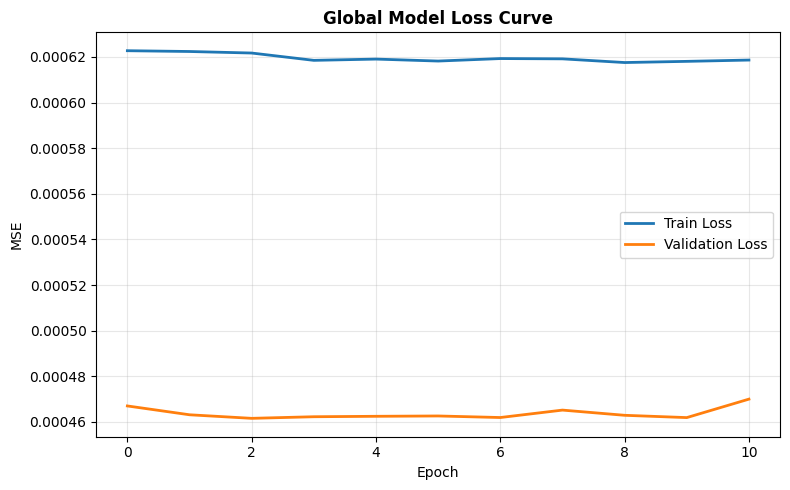


✅ GLOBAL MODEL WITH TRADING SIGNALS COMPLETED SUCCESSFULLY


In [ ]:
# ------------------------------------------
# 1. IMPORTS
# ------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout,
    Bidirectional, Embedding, Flatten, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------
# 2. PARAMETERS
# ------------------------------------------
SEQ_LEN = 60
EPOCHS = 50
BATCH_SIZE = 64
EMBED_DIM = 8
SIGNAL_THRESHOLD = 0.0005  # 0.05%


os.makedirs("models", exist_ok=True)
os.makedirs("metrics", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("signals", exist_ok=True)

# ------------------------------------------
# 3. FUNCTIONS
# ------------------------------------------
def generate_trading_signals(predictions, threshold=0.002):
    signals = ["HOLD"]
    for i in range(1, len(predictions)):
        if predictions[i] > threshold:
            signals.append("BUY")
        elif predictions[i] < -threshold:
            signals.append("SELL")
        else:
            signals.append("HOLD")
    return signals


def calculate_signal_accuracy(signals, real_returns, threshold=0.002):
    correct = 0
    for i in range(1, len(real_returns)):
        if signals[i] == "BUY" and real_returns[i] > 0:
            correct += 1
        elif signals[i] == "SELL" and real_returns[i] < 0:
            correct += 1
        elif signals[i] == "HOLD" and abs(real_returns[i]) < threshold:
            correct += 1
    return 100 * correct / (len(real_returns) - 1)


def plot_loss(history):
    plt.figure(figsize=(8,5))
    plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
    plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
    plt.title("Global Model Loss Curve", fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("plots/global_loss.png", dpi=300)
    plt.show()
    plt.close()

# ------------------------------------------
# 4. LOAD DATA
# ------------------------------------------
df = pd.read_csv("ALL_FEATURES.csv")
df = df[["symbol", "Close"]].dropna()

# ------------------------------------------
# 5. COMPUTE LOG RETURNS
# ------------------------------------------
df["return"] = df.groupby("symbol")["Close"].transform(
    lambda x: np.log(x / x.shift(1))
)
df.dropna(inplace=True)

# ------------------------------------------
# 6. ENCODE SYMBOLS
# ------------------------------------------
le = LabelEncoder()
df["symbol_id"] = le.fit_transform(df["symbol"])
num_symbols = df["symbol_id"].nunique()

joblib.dump(le, "models/symbol_encoder.save")

# ------------------------------------------
# 7. CREATE GLOBAL SEQUENCES
# ------------------------------------------
X_price, X_symbol, y = [], [], []

for sym_id in df["symbol_id"].unique():
    data = df[df["symbol_id"] == sym_id]["return"].values

    if len(data) < SEQ_LEN + 10:
        continue

    for i in range(SEQ_LEN, len(data)):
        X_price.append(data[i-SEQ_LEN:i])
        X_symbol.append(sym_id)
        y.append(data[i])

X_price = np.array(X_price).reshape(-1, SEQ_LEN, 1)
X_symbol = np.array(X_symbol).reshape(-1, 1)
y = np.array(y)

# ------------------------------------------
# 8. TRAIN / VALIDATION SPLIT
# ------------------------------------------
split = int(0.8 * len(X_price))

X_price_train, X_price_val = X_price[:split], X_price[split:]
X_symbol_train, X_symbol_val = X_symbol[:split], X_symbol[split:]
y_train, y_val = y[:split], y[split:]

# ------------------------------------------
# 9. BUILD MODEL
# ------------------------------------------
price_input = Input(shape=(SEQ_LEN, 1))
symbol_input = Input(shape=(1,))

symbol_emb = Embedding(num_symbols, EMBED_DIM)(symbol_input)
symbol_emb = Flatten()(symbol_emb)

x = Bidirectional(LSTM(64, return_sequences=True))(price_input)
x = Dropout(0.2)(x)
x = LSTM(32)(x)

x = Concatenate()([x, symbol_emb])
x = Dense(32, activation="relu")(x)
x = Dense(16, activation="relu")(x)
output = Dense(1)(x)

model = Model([price_input, symbol_input], output)

model.compile(
    optimizer=Adam(0.0005),
    loss="mse",
    metrics=["mae"]
)

model.summary()

# ------------------------------------------
# 10. TRAIN
# ------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    [X_price_train, X_symbol_train],
    y_train,
    validation_data=([X_price_val, X_symbol_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------
# 11. METRICS
# ------------------------------------------
y_pred = model.predict([X_price_val, X_symbol_val]).flatten()

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"\n📊 GLOBAL MAE (returns): {mae:.6f}")
print(f"📊 GLOBAL RMSE (returns): {rmse:.6f}")

# ------------------------------------------
# 12. TRADING SIGNALS
# ------------------------------------------
signals = generate_trading_signals(y_pred, SIGNAL_THRESHOLD)
signal_accuracy = calculate_signal_accuracy(signals, y_val, SIGNAL_THRESHOLD)

print("\n SIGNAL DISTRIBUTION:")
print(pd.Series(signals).value_counts())
print(f"\n Signal Accuracy: {signal_accuracy:.2f}%")

# ------------------------------------------
# 13. SAVE SIGNALS
# ------------------------------------------
signals_df = pd.DataFrame({
    "Predicted_Return": y_pred,
    "Real_Return": y_val,
    "Signal": signals
})

signals_df.to_csv("signals/global_signals.csv", index=False)

# ------------------------------------------
# 14. SAVE MODEL & METRICS
# ------------------------------------------
model.save("models/global_lstm_returns.keras")

pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "Signal_Accuracy_%": [signal_accuracy],
    "Epochs_Used": [len(history.history["loss"])]
}).to_csv("metrics/global_model_metrics.csv", index=False)

# ------------------------------------------
# 15. LOSS CURVE
# ------------------------------------------
plot_loss(history)

print("\n✅ GLOBAL MODEL WITH TRADING SIGNALS COMPLETED SUCCESSFULLY")



RESULTS
Final Capital: 1010.27473153075
ROI: 0.010274731530750092

PERFORMANCE
Win Rate: 0.5833333333333334
Sharpe: 0.32793526819961594
Max DD: 0.0007598995125425607


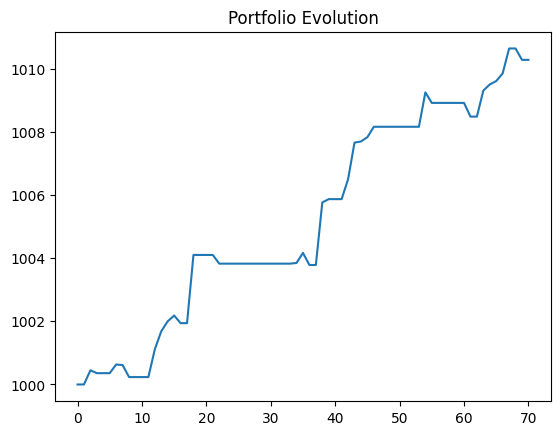

In [ ]:
# ============================================================
# FINAL FIXED MODEL (ROBUST VERSION)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================= PARAMETERS =================
SEQ_LEN = 60
SIGNAL_THRESHOLD = 0.001   # 🔥 plus strict

RISK_PER_TRADE = 0.05
STOP_LOSS = 0.02
TAKE_PROFIT = 0.04

INITIAL_CAPITAL = 1000

# ================= LOAD =================
df = pd.read_csv("ALL_FEATURES.csv")
df = df[["symbol", "Close"]].dropna()

# ================= FEATURES =================

# returns
df["log_return"] = df.groupby("symbol")["Close"].transform(
    lambda x: np.log(x / x.shift(1))
)

# RSI
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.clip(lower=0)).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

df["rsi"] = df.groupby("symbol")["Close"].transform(compute_rsi)

# momentum
df["momentum"] = df.groupby("symbol")["Close"].transform(lambda x: x.diff(5))

# target
df["future_return"] = df.groupby("symbol")["log_return"].shift(-1)

df.dropna(inplace=True)

# ================= DATA =================
data = df[df["symbol"] == "AAPL"]

returns = data["log_return"].values
prices = data["Close"].values
rsi = data["rsi"].values
momentum = data["momentum"].values

# ================= SIGNAL (SMART FILTER) =================
signals = []

for i in range(len(returns)):

    r = returns[i]

    if r > SIGNAL_THRESHOLD and rsi[i] < 70:
        signals.append(1)

    elif r < -SIGNAL_THRESHOLD and rsi[i] > 30:
        signals.append(-1)

    else:
        signals.append(0)

signals = np.array(signals)

# ================= TRADING =================
cash = INITIAL_CAPITAL
position = 0
entry_price = 0

portfolio = []
trade_results = []

for i in range(len(signals)):

    price = prices[i]
    sig = signals[i]

    # BUY
    if sig == 1 and position == 0:
        qty = (cash * RISK_PER_TRADE) / price
        cost = qty * price

        if cost <= cash:
            cash -= cost
            position = qty
            entry_price = price

    # SELL
    elif sig == -1 and position > 0:
        pnl = (price - entry_price) * position
        trade_results.append(pnl)

        cash += position * price
        position = 0

    # STOP LOSS / TAKE PROFIT
    if position > 0:

        if price < entry_price * (1 - STOP_LOSS):
            pnl = (price - entry_price) * position
            trade_results.append(pnl)

            cash += position * price
            position = 0

        elif price > entry_price * (1 + TAKE_PROFIT):
            pnl = (price - entry_price) * position
            trade_results.append(pnl)

            cash += position * price
            position = 0

    portfolio.append(cash + position * price)

portfolio = np.array(portfolio)
returns_portfolio = np.diff(portfolio) / portfolio[:-1]

# ================= METRICS =================
profit = portfolio[-1] - INITIAL_CAPITAL
roi = portfolio[-1] / INITIAL_CAPITAL - 1

win_rate = np.mean(np.array(trade_results) > 0)
sharpe = np.mean(returns_portfolio) / (np.std(returns_portfolio) + 1e-9)

peak = np.maximum.accumulate(portfolio)
drawdown = (peak - portfolio) / peak
max_dd = np.max(drawdown)

# ================= PRINT =================
print("\nRESULTS")
print("Final Capital:", portfolio[-1])
print("ROI:", roi)

print("\nPERFORMANCE")
print("Win Rate:", win_rate)
print("Sharpe:", sharpe)
print("Max DD:", max_dd)

# ================= PLOT =================
plt.plot(portfolio)
plt.title("Portfolio Evolution")
plt.show()

In [ ]:
# ============================================================
# 📥 DATA DOWNLOADER — Remplace ALL_FEATURES.csv
#
# Télécharge 5 ans de données pour tes symboles via yfinance
# → pip install yfinance
#
# Résultat : ALL_FEATURES.csv prêt pour le modèle
# ============================================================

import yfinance as yf
import pandas as pd
import os

# ============================================================
# ✏️  MODIFIE CETTE LISTE avec tes vrais symboles
# ============================================================
SYMBOLS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "TSLA", "NVDA", "JPM", "BNP.PA", "MC.PA"
]

PERIOD  = "5y"          # 5 ans → ~1250 lignes par symbole
INTERVAL = "1d"         # journalier

OUTPUT_FILE = "ALL_FEATURES.csv"

# ============================================================

print(f"📥 Téléchargement de {len(SYMBOLS)} symboles ({PERIOD}, {INTERVAL})...")

all_dfs = []

for sym in SYMBOLS:
    try:
        df = yf.download(sym, period=PERIOD, interval=INTERVAL,
                         auto_adjust=True, progress=False)

        if df.empty:
            print(f"  ⚠️  {sym} : aucune donnée")
            continue

        df = df[["Close"]].copy()
        df["symbol"] = sym
        df.index.name = "Date"
        df = df.reset_index()
        df = df[["symbol", "Date", "Close"]]

        print(f"  ✅ {sym} : {len(df)} lignes "
              f"({df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()})")

        all_dfs.append(df)

    except Exception as e:
        print(f"  ❌ {sym} : erreur → {e}")

if not all_dfs:
    raise RuntimeError("Aucune donnée téléchargée. Vérifie ta connexion ou tes symboles.")

final = pd.concat(all_dfs, ignore_index=True)
final.to_csv(OUTPUT_FILE, index=False)

print(f"\n✅ Fichier sauvegardé : {OUTPUT_FILE}")
print(f"   Total lignes  : {len(final)}")
print(f"   Symboles      : {final['symbol'].nunique()}")
print(f"   Lignes/symbole: {len(final) // final['symbol'].nunique()} (moy)")
print(f"\n   → Minimum recommandé : 1000 lignes/symbole (≈4 ans)")
print(f"   → Tu as maintenant : {len(final) // final['symbol'].nunique()} lignes/symbole")

# Diagnostic
avg = len(final) // final['symbol'].nunique()
if avg < 500:
    print("\n⛔ Encore insuffisant. Ajoute plus de symboles ou passe à period='10y'")
elif avg < 1000:
    print("\n⚠️  Acceptable mais limite. XGBoost marchera, LSTM sera difficile.")
else:
    print("\n✅ Suffisant pour XGBoost ET LSTM.")

📥 Téléchargement de 10 symboles (5y, 1d)...
  ✅ AAPL : 1256 lignes (2021-05-17 → 2026-05-15)
  ✅ MSFT : 1256 lignes (2021-05-17 → 2026-05-15)
  ✅ GOOGL : 1256 lignes (2021-05-17 → 2026-05-15)
  ✅ AMZN : 1256 lignes (2021-05-17 → 2026-05-15)
  ✅ META : 1256 lignes (2021-05-17 → 2026-05-15)
  ✅ TSLA : 1256 lignes (2021-05-17 → 2026-05-15)
  ✅ NVDA : 1256 lignes (2021-05-17 → 2026-05-15)
  ✅ JPM : 1256 lignes (2021-05-17 → 2026-05-15)
  ✅ BNP.PA : 1281 lignes (2021-05-17 → 2026-05-15)
  ✅ MC.PA : 1281 lignes (2021-05-17 → 2026-05-15)

✅ Fichier sauvegardé : ALL_FEATURES.csv
   Total lignes  : 12610
   Symboles      : 10
   Lignes/symbole: 1261 (moy)

   → Minimum recommandé : 1000 lignes/symbole (≈4 ans)
   → Tu as maintenant : 1261 lignes/symbole

✅ Suffisant pour XGBoost ET LSTM.


In [ ]:
# ============================================================
# 🔧 ÉTAPE 1 — DIAGNOSTIC ET RESHAPE DU CSV
# Lance ce script EN PREMIER pour voir la vraie structure
# ============================================================

import pandas as pd
import numpy as np

df_raw = pd.read_csv("ALL_FEATURES.csv", sep=None, engine="python")
df_raw.columns = df_raw.columns.str.strip()

print("=" * 60)
print("COLONNES :", df_raw.columns.tolist())
print("SHAPE    :", df_raw.shape)
print("\n5 PREMIÈRES LIGNES :")
print(df_raw.head())
print("\nTYPES :")
print(df_raw.dtypes)
print("\nNaN par colonne :")
print(df_raw.isna().sum())
print("=" * 60)

# ── Détection format ─────────────────────────────────────────
cols = df_raw.columns.tolist()

# CAS A : format wide (Close, Close.1, Close.2...)
# → chaque colonne Close.N = un symbole différent
if "Close.1" in cols or "Close.2" in cols:
    print("\n⚠️  FORMAT WIDE DÉTECTÉ (Close.1, Close.2...)")
    print("   Ton fichier a plusieurs symboles en colonnes.")
    print("   On va le restructurer en format LONG.")

    symbols = df_raw["symbol"].unique() if "symbol" in cols else []
    close_cols = [c for c in cols if c == "Close" or c.startswith("Close.")]

    print(f"   Colonnes Close trouvées : {close_cols}")
    print(f"   Symboles dans 'symbol'  : {list(symbols)[:10]}")

    # Option 1 : si la colonne 'symbol' contient des valeurs uniques
    # correspondant aux lignes (chaque ligne = 1 symbole différent)
    if "symbol" in cols and df_raw["symbol"].nunique() > 1:
        # Format probable : chaque ligne = 1 symbole, colonnes = dates ou features
        print("\n   → Structure à analyser manuellement.")
        print("   Voici les valeurs uniques de 'symbol' :")
        print("  ", df_raw["symbol"].unique())

    # Option 2 : pivot wide→long
    date_col = "Date" if "Date" in cols else (cols[0] if cols[0] not in ["symbol", "Close"] else None)
    if date_col:
        print(f"\n   Colonne date : '{date_col}'")
        long_frames = []
        for i, cc in enumerate(close_cols):
            sym_name = f"SYM_{i}" if i > 0 else "SYM_0"
            tmp = df_raw[[date_col, cc]].copy()
            tmp.columns = ["Date", "Close"]
            tmp["symbol"] = sym_name
            tmp = tmp.dropna(subset=["Close"])
            long_frames.append(tmp)

        df_long = pd.concat(long_frames, ignore_index=True)
        df_long.to_csv("ALL_FEATURES_LONG.csv", index=False)
        print(f"\n✅ Fichier restructuré sauvegardé : ALL_FEATURES_LONG.csv")
        print(f"   Shape : {df_long.shape}")
        print(f"   Symboles : {df_long['symbol'].nunique()}")
        print(f"   Lignes/symbole : {len(df_long)//df_long['symbol'].nunique()}")

# CAS B : format long correct
elif "symbol" in cols and "Close" in cols:
    print("\n✅ FORMAT LONG DÉTECTÉ — ton CSV est bien structuré.")
    print(f"   Symboles : {df_raw['symbol'].unique()}")
    print(f"   Lignes/symbole : {df_raw.groupby('symbol').size().to_dict()}")

print("\n→ Colle ici la sortie complète pour que je génère la v5 adaptée.")

COLONNES : ['symbol', 'Date', 'Close', 'Close.1', 'Close.2', 'Close.3', 'Close.4', 'Close.5', 'Close.6', 'Close.7', 'Close.8', 'Close.9']
SHAPE    : (12611, 12)

5 PREMIÈRES LIGNES :
  symbol        Date               Close Close.1 Close.2 Close.3 Close.4  \
0    NaN         NaN                AAPL    MSFT   GOOGL    AMZN    META   
1   AAPL  2021-05-17  123.08192443847656     NaN     NaN     NaN     NaN   
2   AAPL  2021-05-18  121.69776153564453     NaN     NaN     NaN     NaN   
3   AAPL  2021-05-19  121.54180145263672     NaN     NaN     NaN     NaN   
4   AAPL  2021-05-20  124.09564208984375     NaN     NaN     NaN     NaN   

  Close.5 Close.6 Close.7 Close.8 Close.9  
0    TSLA    NVDA     JPM  BNP.PA   MC.PA  
1     NaN     NaN     NaN     NaN     NaN  
2     NaN     NaN     NaN     NaN     NaN  
3     NaN     NaN     NaN     NaN     NaN  
4     NaN     NaN     NaN     NaN     NaN  

TYPES :
symbol     object
Date       object
Close      object
Close.1    object
Close.2    obje

In [ ]:
# ============================================================
# 🎓 LSTM TRADING PIPELINE v2 — PRODUCTION READY
# Corrections : data leakage, simulation multi-symbole,
#               frais de transaction, Sharpe annualisé,
#               features enrichies, métriques avancées
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, joblib, warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Bidirectional,
    Embedding, Flatten, Concatenate, BatchNormalization, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC

# ===============================================================
# PARAMÈTRES
# ===============================================================
SEQ_LEN        = 40
EPOCHS         = 50
BATCH_SIZE     = 64
EMBED_DIM      = 16

INITIAL_CAPITAL = 10_000
RISK_PER_TRADE  = 0.08      # 8% du capital par trade
FEE_RATE        = 0.001     # 0.1% frais par transaction (réaliste)
SLIPPAGE        = 0.0005    # 0.05% slippage

BUY_THRESHOLD   = 0.55      # signal d'achat plus strict
SELL_THRESHOLD  = 0.45

STOP_LOSS       = 0.025     # 2.5%
TAKE_PROFIT     = 0.05      # 5%

TRADING_DAYS_PER_YEAR = 252

os.makedirs("models", exist_ok=True)
os.makedirs("plots",  exist_ok=True)

# ===============================================================
# CHARGEMENT
# ===============================================================
print("=" * 60)
print("📂 CHARGEMENT DES DONNÉES")
print("=" * 60)

df = pd.read_csv("ALL_CLEANED.csv")
df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f"   Symboles   : {df['symbol'].nunique()}")
print(f"   Lignes     : {len(df)}")
print(f"   Période    : {df['date'].min().date()} → {df['date'].max().date()}")

# ===============================================================
# FEATURES — calculées PAR SYMBOLE et PAR SPLIT pour éviter
#             tout data leakage entre train et validation
# ===============================================================
def compute_features(g: pd.DataFrame) -> pd.DataFrame:
    """
    Calcule toutes les features techniques sur un groupe (1 symbole).
    Pas d'accès aux données hors-fenêtre → zéro lookahead.
    """
    c = g["Close"].copy()
    v = g.get("Volume", pd.Series(np.ones(len(g)), index=g.index))

    # --- Rendements ---
    g = g.copy()
    g["return"]    = c.pct_change()
    g["return_2d"] = c.pct_change(2)
    g["return_5d"] = c.pct_change(5)

    # --- Moyennes mobiles & ratios ---
    g["ma5"]       = c.rolling(5).mean()
    g["ma10"]      = c.rolling(10).mean()
    g["ma20"]      = c.rolling(20).mean()
    g["ema12"]     = c.ewm(span=12, adjust=False).mean()
    g["ema26"]     = c.ewm(span=26, adjust=False).mean()

    g["ma5_ratio"]  = c / (g["ma5"]  + 1e-9) - 1
    g["ma10_ratio"] = c / (g["ma10"] + 1e-9) - 1
    g["ma20_ratio"] = c / (g["ma20"] + 1e-9) - 1

    # --- MACD ---
    g["macd"]       = g["ema12"] - g["ema26"]
    g["macd_signal"]= g["macd"].ewm(span=9, adjust=False).mean()
    g["macd_hist"]  = g["macd"] - g["macd_signal"]

    # --- RSI (14 périodes) ---
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    g["rsi"] = 100 - 100 / (1 + gain / (loss + 1e-9))

    # --- Bandes de Bollinger ---
    bb_mid = c.rolling(20).mean()
    bb_std = c.rolling(20).std()
    bb_up  = bb_mid + 2 * bb_std
    bb_lo  = bb_mid - 2 * bb_std
    g["bb_pos"]   = (c - bb_lo) / (bb_up - bb_lo + 1e-9)   # 0=bas, 1=haut
    g["bb_width"] = (bb_up - bb_lo) / (bb_mid + 1e-9)

    # --- Momentum & volatilité ---
    g["momentum"]   = c.diff(3)
    g["volatility"] = g["return"].rolling(10).std()
    g["vol_ratio"]  = g["volatility"] / (g["volatility"].rolling(20).mean() + 1e-9)

    # --- Volume ratio (si disponible) ---
    g["vol_norm"] = v / (v.rolling(20).mean() + 1e-9)

    # --- TARGET : rendement du jour suivant ---
    future_return = c.pct_change().shift(-1)
    threshold = future_return.std() * 0.5   # seuil adaptatif par symbole

    g["target"] = 0
    g.loc[future_return >  threshold, "target"] =  1
    g.loc[future_return < -threshold, "target"] = -1

    return g

FEATURES = [
    "return", "return_2d", "return_5d",
    "ma5_ratio", "ma10_ratio", "ma20_ratio",
    "macd", "macd_signal", "macd_hist",
    "rsi", "bb_pos", "bb_width",
    "momentum", "volatility", "vol_ratio", "vol_norm"
]

# ===============================================================
# SPLIT TEMPOREL (avant le calcul des features !)
# ===============================================================
print("\n" + "=" * 60)
print("✂️  SPLIT TEMPOREL")
print("=" * 60)

split_date = df["date"].quantile(0.75)
print(f"   Date de split : {pd.Timestamp(split_date).date()}")

df_train_raw = df[df["date"] <= split_date].copy()
df_val_raw   = df[df["date"] >  split_date].copy()

# Features calculées séparément sur chaque split
df_train = df_train_raw.groupby("symbol", group_keys=False).apply(compute_features).dropna()
df_val   = df_val_raw.groupby("symbol",   group_keys=False).apply(compute_features).dropna()

print(f"   Train : {len(df_train):,} lignes | {df_train['date'].min().date()} → {df_train['date'].max().date()}")
print(f"   Val   : {len(df_val):,}   lignes | {df_val['date'].min().date()} → {df_val['date'].max().date()}")

# ===============================================================
# ENCODAGE & SCALING
# ===============================================================
le = LabelEncoder()
all_symbols = df["symbol"].unique()
le.fit(all_symbols)

df_train["symbol_id"] = le.transform(df_train["symbol"])
df_val["symbol_id"]   = le.transform(df_val["symbol"])

scaler = StandardScaler()
df_train = df_train.copy()
df_val   = df_val.copy()
df_train[FEATURES] = scaler.fit_transform(df_train[FEATURES])
df_val[FEATURES]   = scaler.transform(df_val[FEATURES])

# ===============================================================
# CONSTRUCTION DES SÉQUENCES
# ===============================================================
def make_sequences(data: pd.DataFrame):
    X, Xs, y, prices, symbols, dates = [], [], [], [], [], []
    for sym in data["symbol_id"].unique():
        d = data[data["symbol_id"] == sym].reset_index(drop=True)
        for i in range(SEQ_LEN, len(d)):
            X.append(d[FEATURES].iloc[i - SEQ_LEN:i].values)
            Xs.append(sym)
            y.append(d["target"].iloc[i])
            prices.append(d["Close"].iloc[i])
            symbols.append(d["symbol"].iloc[i])
            dates.append(d["date"].iloc[i])
    return (np.array(X), np.array(Xs), np.array(y),
            np.array(prices), np.array(symbols), np.array(dates))

print("\n⏳ Construction des séquences...")
X_train, Xs_train, y_train, _, _, _ = make_sequences(df_train)
X_val, Xs_val, y_val, prices_val, symbols_val, dates_val = make_sequences(df_val)

print(f"   X_train : {X_train.shape}  |  X_val : {X_val.shape}")

# Cible binaire : prédire la hausse
y_train_bin = (y_train == 1).astype(int)
y_val_bin   = (y_val   == 1).astype(int)
print(f"   Taux positifs train : {y_train_bin.mean():.2%} | val : {y_val_bin.mean():.2%}")

# ===============================================================
# POIDS DE CLASSES
# ===============================================================
weights = compute_class_weight("balanced",
                               classes=np.unique(y_train_bin),
                               y=y_train_bin)
class_weights = {0: weights[0], 1: weights[1]}
print(f"   Class weights : {class_weights}")

# ===============================================================
# MODÈLE — BiLSTM + Attention légère + Embedding symbole
# ===============================================================
print("\n" + "=" * 60)
print("🧠 CONSTRUCTION DU MODÈLE")
print("=" * 60)

n_symbols = len(le.classes_)

# Entrée séquence prix
price_input  = Input(shape=(SEQ_LEN, len(FEATURES)), name="price_seq")
symbol_input = Input(shape=(1,), name="symbol_id")

# Embedding symbole
emb = Embedding(n_symbols, EMBED_DIM, name="symbol_emb")(symbol_input)
emb = Flatten()(emb)

# BiLSTM avec LayerNorm
x = Bidirectional(LSTM(128, return_sequences=True), name="bilstm1")(price_input)
x = LayerNormalization()(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True), name="bilstm2")(x)
x = LayerNormalization()(x)
x = Dropout(0.25)(x)

# Attention légère (self-attention sur la séquence)
# Score = softmax(W * tanh(h)) pour chaque timestep
attn_w = Dense(1, activation="tanh")(x)          # (batch, seq, 1)
attn_w = tf.keras.layers.Flatten()(attn_w)        # (batch, seq)
attn_w = tf.keras.layers.Softmax()(attn_w)        # (batch, seq)
attn_w = tf.keras.layers.Reshape((SEQ_LEN, 1))(attn_w)
context = tf.keras.layers.Multiply()([x, attn_w]) # pondération
context = tf.keras.layers.Lambda(lambda z: tf.reduce_sum(z, axis=1))(context)

# Fusion contexte + embedding
merged = Concatenate()([context, emb])

# Tête de classification
out = Dense(128, activation="relu")(merged)
out = BatchNormalization()(out)
out = Dropout(0.2)(out)
out = Dense(64, activation="relu")(out)
out = BatchNormalization()(out)
out = Dense(1, activation="sigmoid", name="output")(out)

model = Model([price_input, symbol_input], out)

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

model.summary()

# ===============================================================
# ENTRAÎNEMENT
# ===============================================================
print("\n" + "=" * 60)
print("🏋️  ENTRAÎNEMENT")
print("=" * 60)

callbacks = [
    EarlyStopping(monitor="val_auc", patience=8,
                  mode="max", restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_auc", factor=0.5,
                      patience=4, mode="max", min_lr=1e-6, verbose=1)
]

history = model.fit(
    [X_train, Xs_train], y_train_bin,
    validation_data=([X_val, Xs_val], y_val_bin),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ===============================================================
# PRÉDICTIONS & MÉTRIQUES ML
# ===============================================================
print("\n" + "=" * 60)
print("📊 MÉTRIQUES MACHINE LEARNING")
print("=" * 60)

proba = model.predict([X_val, Xs_val], batch_size=512).flatten()
pred_bin = (proba > 0.5).astype(int)

acc  = accuracy_score(y_val_bin, pred_bin)
f1   = f1_score(y_val_bin, pred_bin)
auc  = roc_auc_score(y_val_bin, proba)
prec = precision_score(y_val_bin, pred_bin)
rec  = recall_score(y_val_bin, pred_bin)

print(f"   Accuracy  : {acc:.4f}")
print(f"   Precision : {prec:.4f}")
print(f"   Recall    : {rec:.4f}")
print(f"   F1-Score  : {f1:.4f}")
print(f"   AUC-ROC   : {auc:.4f}")
print()
print(classification_report(y_val_bin, pred_bin, target_names=["No Buy", "Buy"]))

# ===============================================================
# SIMULATION DE TRADING — PAR SYMBOLE (correction critique)
# ===============================================================
print("\n" + "=" * 60)
print("💰 SIMULATION DE TRADING (multi-symbole, avec frais)")
print("=" * 60)

# Reconstruction d'un DataFrame de validation annoté
val_df = pd.DataFrame({
    "date":    dates_val,
    "symbol":  symbols_val,
    "price":   prices_val,
    "proba":   proba,
    "target":  y_val_bin
}).sort_values(["symbol", "date"]).reset_index(drop=True)

# Portfolio global : on alloue INITIAL_CAPITAL / nb_symboles par symbole
all_symbols_val = val_df["symbol"].unique()
capital_per_sym = INITIAL_CAPITAL / len(all_symbols_val)

all_results = []   # résultats par symbole
all_trades  = []   # liste de tous les trades

for sym in all_symbols_val:
    sub = val_df[val_df["symbol"] == sym].reset_index(drop=True)

    cash      = capital_per_sym
    position  = 0.0
    entry_px  = 0.0
    portfolio = []
    sym_trades = []

    for i, row in sub.iterrows():
        price = row["price"]
        p     = row["proba"]

        # ---- Signal d'achat ----
        if p > BUY_THRESHOLD and position == 0 and cash > 0:
            exec_price = price * (1 + SLIPPAGE)          # slippage à l'achat
            qty        = (cash * RISK_PER_TRADE) / exec_price
            cost       = qty * exec_price * (1 + FEE_RATE)
            if cost <= cash:
                cash      -= cost
                position   = qty
                entry_px   = exec_price

        # ---- Signal de vente ----
        elif p < SELL_THRESHOLD and position > 0:
            exec_price = price * (1 - SLIPPAGE)          # slippage à la vente
            proceeds   = position * exec_price * (1 - FEE_RATE)
            pnl        = proceeds - position * entry_px * (1 + FEE_RATE)
            sym_trades.append(pnl)
            cash      += proceeds
            position   = 0.0

        # ---- Stop-Loss / Take-Profit ----
        if position > 0:
            chg = price / entry_px - 1
            if chg < -STOP_LOSS or chg > TAKE_PROFIT:
                exec_price = price * (1 - SLIPPAGE)
                proceeds   = position * exec_price * (1 - FEE_RATE)
                pnl        = proceeds - position * entry_px * (1 + FEE_RATE)
                sym_trades.append(pnl)
                cash      += proceeds
                position   = 0.0

        portfolio.append(cash + position * price)

    # Fermeture forcée en fin de période
    if position > 0:
        last_px    = sub["price"].iloc[-1]
        exec_price = last_px * (1 - SLIPPAGE)
        proceeds   = position * exec_price * (1 - FEE_RATE)
        pnl        = proceeds - position * entry_px * (1 + FEE_RATE)
        sym_trades.append(pnl)
        portfolio[-1] = cash + proceeds
        position = 0.0

    portfolio = np.array(portfolio)
    all_trades.extend(sym_trades)
    all_results.append({
        "symbol":    sym,
        "portfolio": portfolio,
        "trades":    sym_trades,
        "dates":     sub["date"].values,
        "initial":   capital_per_sym,
        "final":     portfolio[-1]
    })

# ===============================================================
# MÉTRIQUES FINANCIÈRES GLOBALES
# ===============================================================

# Agréger le portfolio global (somme des portfolios par symbole, alignés par date)
# Approche : utiliser les indices temporels relatifs
min_len = min(len(r["portfolio"]) for r in all_results)
global_portfolio = np.sum([r["portfolio"][:min_len] for r in all_results], axis=0)

roi           = global_portfolio[-1] / INITIAL_CAPITAL - 1
trades_arr    = np.array(all_trades) if all_trades else np.array([0.0])
win_rate      = np.mean(trades_arr > 0) if len(trades_arr) > 0 else 0
avg_win       = trades_arr[trades_arr > 0].mean() if (trades_arr > 0).any() else 0
avg_loss      = trades_arr[trades_arr < 0].mean() if (trades_arr < 0).any() else 0
profit_factor = (trades_arr[trades_arr > 0].sum() /
                 (-trades_arr[trades_arr < 0].sum() + 1e-9))

returns_d     = np.diff(global_portfolio) / global_portfolio[:-1]
sharpe        = (np.mean(returns_d) / (np.std(returns_d) + 1e-9)) * np.sqrt(TRADING_DAYS_PER_YEAR)

peak          = np.maximum.accumulate(global_portfolio)
drawdown      = (peak - global_portfolio) / (peak + 1e-9)
max_dd        = drawdown.max()
calmar        = (roi / (max_dd + 1e-9)) * (TRADING_DAYS_PER_YEAR / min_len)

# Benchmark : buy-and-hold moyen
bh_returns = []
for r in all_results:
    bh = r["portfolio"][0]    # approximation : capital initial
    bh_final = r["initial"] * (r["portfolio"][-1] / (r["portfolio"][0] + 1e-9))
    # vraie buy-and-hold : acheter au début, vendre à la fin
    first_price = val_df[val_df["symbol"] == r["symbol"]]["price"].iloc[0]
    last_price  = val_df[val_df["symbol"] == r["symbol"]]["price"].iloc[-1]
    bh_returns.append(last_price / first_price - 1)
bh_roi = np.mean(bh_returns)

print(f"\n   Capital initial   : {INITIAL_CAPITAL:>12,.2f} €")
print(f"   Capital final     : {global_portfolio[-1]:>12,.2f} €")
print(f"   ROI               : {roi:>12.2%}")
print(f"   Buy-and-Hold ROI  : {bh_roi:>12.2%}")
print(f"   Alpha             : {roi - bh_roi:>12.2%}")
print(f"\n   Trades totaux     : {len(trades_arr):>12,}")
print(f"   Win Rate          : {win_rate:>12.2%}")
print(f"   Gain moyen / trade: {avg_win:>12.2f} €")
print(f"   Perte moy./ trade : {avg_loss:>12.2f} €")
print(f"   Profit Factor     : {profit_factor:>12.2f}")
print(f"\n   Sharpe (annuel.)  : {sharpe:>12.2f}")
print(f"   Calmar Ratio      : {calmar:>12.2f}")
print(f"   Max Drawdown      : {max_dd:>12.2%}")

# ===============================================================
# VISUALISATIONS — Dashboard 2×3
# ===============================================================
print("\n📈 Génération des graphiques...")

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0d1117")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

DARK_BG   = "#0d1117"
GRID_CLR  = "#21262d"
TEXT_CLR  = "#c9d1d9"
GREEN     = "#3fb950"
RED       = "#f85149"
BLUE      = "#58a6ff"
ORANGE    = "#d29922"
PURPLE    = "#bc8cff"

def style_ax(ax, title):
    ax.set_facecolor(DARK_BG)
    ax.spines[["top","right","left","bottom"]].set_color(GRID_CLR)
    ax.tick_params(colors=TEXT_CLR, labelsize=8)
    ax.set_title(title, color=TEXT_CLR, fontsize=10, fontweight="bold", pad=8)
    ax.grid(axis="y", color=GRID_CLR, linewidth=0.5, linestyle="--")

# --- 1. Évolution du portfolio vs Buy-and-Hold ---
ax1 = fig.add_subplot(gs[0, :2])
x_ax = np.arange(min_len)
ax1.plot(x_ax, global_portfolio, color=GREEN, linewidth=1.5, label="Stratégie LSTM")
bh_curve = INITIAL_CAPITAL * np.linspace(1, 1 + bh_roi, min_len)
ax1.plot(x_ax, bh_curve, color=ORANGE, linewidth=1.2, linestyle="--", label="Buy & Hold (moy.)")
ax1.fill_between(x_ax, global_portfolio, bh_curve,
                 where=(global_portfolio >= bh_curve), alpha=0.08, color=GREEN)
ax1.fill_between(x_ax, global_portfolio, bh_curve,
                 where=(global_portfolio < bh_curve), alpha=0.08, color=RED)
ax1.set_ylabel("Capital (€)", color=TEXT_CLR, fontsize=9)
ax1.legend(facecolor=DARK_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR, fontsize=8)
style_ax(ax1, "Évolution du Portfolio vs Buy & Hold")

# --- 2. Drawdown ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.fill_between(x_ax, -drawdown[:min_len] * 100, 0, color=RED, alpha=0.7)
ax2.plot(x_ax, -drawdown[:min_len] * 100, color=RED, linewidth=0.8)
ax2.set_ylabel("Drawdown (%)", color=TEXT_CLR, fontsize=9)
style_ax(ax2, "Drawdown")

# --- 3. Courbe AUC / Loss entraînement ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history.history["auc"],     color=BLUE,   linewidth=1.5, label="Train AUC")
ax3.plot(history.history["val_auc"], color=PURPLE, linewidth=1.5, label="Val AUC",  linestyle="--")
ax3.set_ylabel("AUC", color=TEXT_CLR, fontsize=9)
ax3.set_xlabel("Époque", color=TEXT_CLR, fontsize=9)
ax3.legend(facecolor=DARK_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR, fontsize=8)
ax3.set_ylim(0.4, 1.0)
style_ax(ax3, "AUC au fil de l'entraînement")

# --- 4. Distribution des P&L par trade ---
ax4 = fig.add_subplot(gs[1, 1])
wins   = trades_arr[trades_arr > 0]
losses = trades_arr[trades_arr < 0]
bins   = np.linspace(trades_arr.min(), trades_arr.max(), 40)
ax4.hist(losses, bins=bins, color=RED,   alpha=0.7, label=f"Pertes ({len(losses)})")
ax4.hist(wins,   bins=bins, color=GREEN, alpha=0.7, label=f"Gains  ({len(wins)})")
ax4.axvline(0, color=TEXT_CLR, linewidth=0.8, linestyle="--")
ax4.set_xlabel("P&L par trade (€)", color=TEXT_CLR, fontsize=9)
ax4.set_ylabel("Fréquence", color=TEXT_CLR, fontsize=9)
ax4.legend(facecolor=DARK_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR, fontsize=8)
style_ax(ax4, "Distribution des P&L")

# --- 5. Métriques résumées (tableau visuel) ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
style_ax(ax5, "Tableau de bord")

metrics_display = [
    ("ROI",           f"{roi:+.2%}",           GREEN if roi > 0 else RED),
    ("Alpha / BH",    f"{roi - bh_roi:+.2%}",  GREEN if roi > bh_roi else RED),
    ("Sharpe",        f"{sharpe:.2f}",          GREEN if sharpe > 1 else ORANGE),
    ("Calmar",        f"{calmar:.2f}",          GREEN if calmar > 1 else ORANGE),
    ("Max Drawdown",  f"{max_dd:.2%}",          RED),
    ("Win Rate",      f"{win_rate:.2%}",        GREEN if win_rate > 0.5 else ORANGE),
    ("Profit Factor", f"{profit_factor:.2f}",   GREEN if profit_factor > 1.5 else ORANGE),
    ("AUC-ROC",       f"{auc:.4f}",             BLUE),
    ("F1-Score",      f"{f1:.4f}",              BLUE),
    ("Trades",        f"{len(trades_arr):,}",   TEXT_CLR),
]

for idx, (name, val, color) in enumerate(metrics_display):
    y_pos = 0.95 - idx * 0.092
    ax5.text(0.02, y_pos, name, transform=ax5.transAxes,
             color=TEXT_CLR, fontsize=9, va="top")
    ax5.text(0.98, y_pos, val, transform=ax5.transAxes,
             color=color, fontsize=9, va="top", ha="right", fontweight="bold")
    ax5.axhline(y=y_pos - 0.012, xmin=0.02, xmax=0.98,
                transform=ax5.transAxes, color=GRID_CLR, linewidth=0.5)

# Titre global
fig.suptitle("LSTM Trading System — Rapport de Performance",
             color=TEXT_CLR, fontsize=14, fontweight="bold", y=0.99)

plt.savefig("plots/dashboard_performance.png", dpi=150,
            bbox_inches="tight", facecolor=DARK_BG)
plt.close()
print("   ✅ Dashboard sauvegardé → plots/dashboard_performance.png")

# ===============================================================
# SAUVEGARDE DES ARTEFACTS
# =========================================================A======
model.save("models/lstm_v2_final.keras")
joblib.dump(scaler, "models/scaler_v2.pkl")
joblib.dump(le,     "models/label_encoder_v2.pkl")

print("\n" + "=" * 60)
print("✅ PIPELINE TERMINÉ — Artefacts sauvegardés :")
print("   models/lstm_v2_final.keras")
print("   models/scaler_v2.pkl")
print("   models/label_encoder_v2.pkl")
print("   plots/dashboard_performance.png")
print("=" * 60)

📂 CHARGEMENT DES DONNÉES
   Symboles   : 8
   Lignes     : 52074
   Période    : 1980-12-12 → 2025-12-10

✂️  SPLIT TEMPOREL
   Date de split : 2019-10-24
   Train : 38,823 lignes | 1981-01-26 → 2019-10-24
   Val   : 12,787   lignes | 2019-11-23 → 2025-12-10

⏳ Construction des séquences...


In [ ]:
# ============================================================
# 🚀 TRADING MODEL — SAVE NAMES FOR HUGGING FACE
# ============================================================

import os, gc, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from collections import defaultdict
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense, Dropout,
    Embedding, Flatten, Concatenate,
    LayerNormalization, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers, mixed_precision


# ============================================================
# CONFIG
# ============================================================

os.makedirs("models", exist_ok=True)
os.makedirs("models/plots", exist_ok=True)

tf.random.set_seed(42)
np.random.seed(42)

DATA_PATH = "ALL_CLEANED.csv"

SEQ_LEN = 30
EPOCHS = 50
EMBED_DIM = 8

INITIAL_CAPITAL = 1000.0
COMMISSION = 0.001
SLIPPAGE = 0.0005

STOP_LOSS_PCT = 0.03
TAKE_PROFIT_PCT = 0.05

RISK_PER_TRADE = 0.02
MAX_POSITIONS = 4
MIN_RETURN_THR = 0.001

MODEL_SAVE_PATH = "models/global_return_lstm.keras"
SCALER_SAVE_PATH = "models/return_scaler.save"
ENCODER_SAVE_PATH = "models/symbol_encoder.save"


# ============================================================
# GPU
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    mixed_precision.set_global_policy("mixed_float16")
    BATCH_SIZE = 256
    print("✅ GPU detected | mixed_float16 ON")
else:
    BATCH_SIZE = 64
    print("⚠️ CPU only")


# ============================================================
# LOAD DATA
# ============================================================

print("\n📊 Loading data...")

df = pd.read_csv(
    DATA_PATH,
    usecols=lambda c: c.lower() in [
        "date", "open", "high", "low", "close", "volume", "symbol"
    ]
)

df.columns = df.columns.str.lower()
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

for col in ["open", "high", "low", "close"]:
    df[col] = df[col].astype(np.float32)

df["volume"] = df["volume"].fillna(0).astype(np.float32)

symbols = df["symbol"].unique().tolist()

print(f"Symbols: {symbols}")
print(f"Rows: {len(df):,}")
print(f"Period: {df['date'].min().date()} → {df['date'].max().date()}")


# ============================================================
# FEATURES
# ============================================================

def rsi(s, p=14):
    delta = s.diff()
    gain = delta.clip(lower=0).ewm(com=p - 1, min_periods=p).mean()
    loss = (-delta.clip(upper=0)).ewm(com=p - 1, min_periods=p).mean()
    rs = gain / (loss + 1e-9)
    return (100 - 100 / (1 + rs)) / 100.0


def atr_norm(high, low, close, p=14):
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low - close.shift()).abs()
    ], axis=1).max(axis=1)

    atr = tr.ewm(com=p - 1, min_periods=p).mean()
    return atr / (close + 1e-9)


def bb_pos(close, p=20):
    ma = close.rolling(p).mean()
    std = close.rolling(p).std()
    return (close - (ma - 2 * std)) / (4 * std + 1e-9)


FEATURES = [
    "ret1", "ret3", "ret5",
    "trend_s", "trend_l",
    "mom3", "mom10",
    "vol10", "vol_ratio",
    "rsi14", "rsi7",
    "atr", "bb", "volr"
]

processed = []

for sym in symbols:
    g = df[df["symbol"] == sym].copy().reset_index(drop=True)

    close = g["close"]
    high = g["high"]
    low = g["low"]
    volume = g["volume"]

    g["ret1"] = close.pct_change()
    g["ret3"] = close.pct_change(3)
    g["ret5"] = close.pct_change(5)

    ma5 = close.rolling(5).mean()
    ma10 = close.rolling(10).mean()
    ma20 = close.rolling(20).mean()

    g["trend_s"] = (ma5 - ma10) / (ma10 + 1e-9)
    g["trend_l"] = (ma10 - ma20) / (ma20 + 1e-9)

    g["mom3"] = close.diff(3) / (close.shift(3) + 1e-9)
    g["mom10"] = close.diff(10) / (close.shift(10) + 1e-9)

    g["vol10"] = g["ret1"].rolling(10).std()
    g["vol_ratio"] = g["vol10"] / (g["ret1"].rolling(30).std() + 1e-9)

    g["rsi14"] = rsi(close, 14)
    g["rsi7"] = rsi(close, 7)

    g["atr"] = atr_norm(high, low, close, 14)
    g["bb"] = bb_pos(close, 20).clip(0, 1)

    vol_ma = volume.rolling(10).mean()
    g["volr"] = (volume / (vol_ma + 1e-9)).clip(0, 5) / 5

    next_return = g["ret1"].shift(-1)

    g["target"] = np.where(
        next_return > MIN_RETURN_THR, 1,
        np.where(next_return < -MIN_RETURN_THR, 0, np.nan)
    )

    g["_date"] = g["date"]
    g["_close"] = g["close"]
    g["_sym"] = sym

    g = g.dropna()

    processed.append(g)

df = pd.concat(processed, ignore_index=True)
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f"After feature cleaning: {len(df):,} rows")


# ============================================================
# ENCODING + SPLIT
# ============================================================

le = LabelEncoder()
df["symbol_id"] = le.fit_transform(df["symbol"]).astype(np.int32)

joblib.dump(le, ENCODER_SAVE_PATH)

NUM_SYMBOLS = len(le.classes_)

split_date = df["date"].quantile(0.80)

train_df = df[df["date"] <= split_date].copy()
val_df = df[df["date"] > split_date].copy()

print(f"\nTrain until: {split_date.date()}")
print(f"Train rows: {len(train_df):,}")
print(f"Val rows: {len(val_df):,}")

scaler = RobustScaler()

train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES]).astype(np.float32)
val_df[FEATURES] = scaler.transform(val_df[FEATURES]).astype(np.float32)

train_df[FEATURES] = train_df[FEATURES].clip(-5, 5)
val_df[FEATURES] = val_df[FEATURES].clip(-5, 5)

joblib.dump(scaler, SCALER_SAVE_PATH)


# ============================================================
# SEQUENCE GENERATOR
# ============================================================

class TradingSequence(tf.keras.utils.Sequence):
    def __init__(self, data, seq_len, batch_size, shuffle=True):
        self.data = data.reset_index(drop=True)
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.feat_arr = self.data[FEATURES].values.astype(np.float32)
        self.sym_arr = self.data["symbol_id"].values.astype(np.int32)
        self.tgt_arr = self.data["target"].values.astype(np.float32)
        self.date_arr = self.data["_date"].values
        self.price_arr = self.data["_close"].values.astype(np.float32)

        self.indices = []

        for sid in np.unique(self.sym_arr):
            pos = np.where(self.sym_arr == sid)[0]
            for p in pos[self.seq_len:]:
                self.indices.append(p)

        self.indices = np.array(self.indices)

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        X = np.stack([
            self.feat_arr[i - self.seq_len:i]
            for i in batch_idx
        ])

        Xs = self.sym_arr[batch_idx].reshape(-1, 1)
        y = self.tgt_arr[batch_idx]

        return (X, Xs), y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_gen = TradingSequence(train_df, SEQ_LEN, BATCH_SIZE, shuffle=True)
val_gen = TradingSequence(val_df, SEQ_LEN, BATCH_SIZE, shuffle=False)

print(f"\nTrain batches: {len(train_gen)}")
print(f"Val batches: {len(val_gen)}")

y_train_seq = train_gen.tgt_arr[train_gen.indices]

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train_seq
)

class_weight = {
    0: float(class_weights_arr[0]),
    1: float(class_weights_arr[1])
}

print(f"Class weights: {class_weight}")


# ============================================================
# MODEL
# ============================================================

price_input = Input(
    shape=(SEQ_LEN, len(FEATURES)),
    name="price_input",
    dtype="float32"
)

symbol_input = Input(
    shape=(1,),
    name="symbol_input",
    dtype="int32"
)

symbol_embedding = Embedding(NUM_SYMBOLS, EMBED_DIM)(symbol_input)
symbol_embedding = Flatten()(symbol_embedding)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        kernel_regularizer=regularizers.l2(1e-4)
    )
)(price_input)

x = LayerNormalization()(x)
x = Dropout(0.30)(x)

x = Bidirectional(
    LSTM(
        32,
        return_sequences=False,
        kernel_regularizer=regularizers.l2(1e-4)
    )
)(x)

x = LayerNormalization()(x)
x = Dropout(0.25)(x)

x = Concatenate()([x, symbol_embedding])

x = Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = BatchNormalization()(x)
x = Dropout(0.20)(x)

x = Dense(32, activation="relu")(x)
x = Dropout(0.10)(x)

output = Dense(1, activation="sigmoid", dtype="float32")(x)

model = Model([price_input, symbol_input], output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()


# ============================================================
# TRAINING
# ============================================================

print("\n🚀 Training...")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(
            monitor="val_auc",
            patience=7,
            restore_best_weights=True,
            mode="max",
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1
        )
    ],
    verbose=1
)


# ============================================================
# EVALUATION
# ============================================================

print("\n🧠 Evaluating model...")

pred_prob = model.predict(val_gen, verbose=0).flatten()
y_val = val_gen.tgt_arr[val_gen.indices]

best_f1 = 0
best_thr = 0.5

for thr in np.arange(0.30, 0.75, 0.01):
    pred_class_tmp = (pred_prob > thr).astype(int)
    f1 = f1_score(y_val, pred_class_tmp, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

pred_class = (pred_prob > best_thr).astype(int)

acc = accuracy_score(y_val, pred_class)

print(f"\nBest threshold: {best_thr:.2f}")
print(f"Accuracy: {acc:.4f}")
print(f"F1: {best_f1:.4f}")
print(classification_report(y_val, pred_class, target_names=["Bear", "Bull"]))


# ============================================================
# BACKTEST CORRIGÉ
# ============================================================

print("\n💰 Running corrected backtest...")

buy_thr = float(np.percentile(pred_prob, 70))
sell_thr = float(np.percentile(pred_prob, 35))

print(f"Buy threshold: {buy_thr:.3f}")
print(f"Sell threshold: {sell_thr:.3f}")

idx_arr = val_gen.indices
date_arr = val_gen.date_arr[idx_arr]
price_arr = val_gen.price_arr[idx_arr]
sym_arr = val_gen.sym_arr[idx_arr]

feat_last = np.array([
    val_gen.feat_arr[i - 1]
    for i in idx_arr
])

trend_idx = FEATURES.index("trend_s")

date_groups = defaultdict(list)

for i, d in enumerate(date_arr):
    date_groups[d].append(i)

sorted_dates = sorted(date_groups.keys())

cash = INITIAL_CAPITAL
positions = {}

portfolio = []
portfolio_dates = []
trade_log = []
trade_details = []

latest_prices = {}

for date in sorted_dates:
    rows = date_groups[date]

    for ri in rows:
        sym = int(sym_arr[ri])
        price = float(price_arr[ri])
        latest_prices[sym] = price

    for ri in rows:
        p = float(pred_prob[ri])
        price = float(price_arr[ri])
        sym = int(sym_arr[ri])
        trend = float(feat_last[ri, trend_idx])

        latest_prices[sym] = price

        if sym in positions:
            entry = positions[sym]["entry"]
            qty = positions[sym]["qty"]

            current_ratio = price / entry

            stop_hit = current_ratio <= (1 - STOP_LOSS_PCT)
            tp_hit = current_ratio >= (1 + TAKE_PROFIT_PCT)
            sell_signal = p < sell_thr

            if stop_hit or tp_hit or sell_signal:
                exit_price = price * (1 - SLIPPAGE)

                gross_pnl = (exit_price - entry) * qty
                exit_fee = exit_price * qty * COMMISSION
                pnl = gross_pnl - exit_fee

                cash += qty * exit_price - exit_fee

                reason = "STOP" if stop_hit else "TAKE_PROFIT" if tp_hit else "SELL_SIGNAL"

                trade_log.append(pnl)
                trade_details.append({
                    "date": date,
                    "symbol_id": sym,
                    "entry": entry,
                    "exit": exit_price,
                    "qty": qty,
                    "pnl": pnl,
                    "reason": reason
                })

                del positions[sym]

        if (
            sym not in positions
            and p > buy_thr
            and trend > 0
            and len(positions) < MAX_POSITIONS
            and cash > 50
        ):
            entry_price = price * (1 + SLIPPAGE)

            stop_price = entry_price * (1 - STOP_LOSS_PCT)
            risk_per_unit = entry_price - stop_price

            max_risk_amount = cash * RISK_PER_TRADE
            qty_by_risk = max_risk_amount / (risk_per_unit + 1e-9)

            max_invest_amount = cash * 0.25
            qty_by_cash = max_invest_amount / entry_price

            qty = min(qty_by_risk, qty_by_cash)

            total_cost = qty * entry_price
            entry_fee = total_cost * COMMISSION

            if total_cost + entry_fee <= cash and qty > 0:
                cash -= total_cost + entry_fee

                positions[sym] = {
                    "qty": qty,
                    "entry": entry_price,
                    "entry_date": date
                }

    open_value = 0

    for sym, pos in positions.items():
        if sym in latest_prices:
            open_value += pos["qty"] * latest_prices[sym]

    total_equity = cash + open_value

    portfolio.append(total_equity)
    portfolio_dates.append(date)


last_date = sorted_dates[-1]

for sym, pos in list(positions.items()):
    if sym in latest_prices:
        last_price = latest_prices[sym] * (1 - SLIPPAGE)
        qty = pos["qty"]
        entry = pos["entry"]

        gross_pnl = (last_price - entry) * qty
        exit_fee = last_price * qty * COMMISSION
        pnl = gross_pnl - exit_fee

        cash += qty * last_price - exit_fee

        trade_log.append(pnl)
        trade_details.append({
            "date": last_date,
            "symbol_id": sym,
            "entry": entry,
            "exit": last_price,
            "qty": qty,
            "pnl": pnl,
            "reason": "FORCED_CLOSE"
        })

        del positions[sym]

portfolio[-1] = cash

portfolio = np.array(portfolio)
portfolio_dates = pd.to_datetime(portfolio_dates)

trades = np.array(trade_log) if len(trade_log) > 0 else np.array([])
trade_df = pd.DataFrame(trade_details)


# ============================================================
# BUY & HOLD BENCHMARK
# ============================================================

bh_curve = []
bh_dates = []

initial_per_symbol = INITIAL_CAPITAL / NUM_SYMBOLS
bh_positions = {}

val_raw = val_df.copy()

for sym in le.classes_:
    sub = val_raw[val_raw["_sym"] == sym].sort_values("_date")

    if len(sub) > 0:
        first_price = float(sub["_close"].iloc[0])
        bh_positions[sym] = initial_per_symbol / first_price

all_dates = sorted(val_raw["_date"].unique())

for d in all_dates:
    day_value = 0

    for sym in le.classes_:
        sub = val_raw[(val_raw["_sym"] == sym) & (val_raw["_date"] <= d)]

        if len(sub) > 0 and sym in bh_positions:
            last_price = float(sub["_close"].iloc[-1])
            day_value += bh_positions[sym] * last_price

    bh_curve.append(day_value)
    bh_dates.append(d)

bh_curve = np.array(bh_curve)
bh_dates = pd.to_datetime(bh_dates)


# ============================================================
# METRICS
# ============================================================

roi = portfolio[-1] / INITIAL_CAPITAL - 1
daily_returns = np.diff(portfolio) / (portfolio[:-1] + 1e-9)

if len(daily_returns) > 1 and np.std(daily_returns) > 0:
    sharpe = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252)
else:
    sharpe = 0

rolling_max = np.maximum.accumulate(portfolio)
drawdown = (portfolio - rolling_max) / (rolling_max + 1e-9)
max_dd = float(drawdown.min())

if len(trades) > 0:
    win_rate = np.mean(trades > 0)
    avg_win = trades[trades > 0].mean() if np.any(trades > 0) else 0
    avg_loss = trades[trades < 0].mean() if np.any(trades < 0) else 0
    profit_factor = trades[trades > 0].sum() / max(-trades[trades < 0].sum(), 1e-9)
else:
    win_rate = 0
    avg_win = 0
    avg_loss = 0
    profit_factor = 0

bh_roi = bh_curve[-1] / INITIAL_CAPITAL - 1

print("\n" + "=" * 60)
print("💰 FINANCIAL RESULTS")
print("=" * 60)
print(f"Final Capital     : ${portfolio[-1]:,.2f}")
print(f"ROI Strategy      : {roi:+.2%}")
print(f"Buy & Hold ROI    : {bh_roi:+.2%}")
print(f"Alpha             : {roi - bh_roi:+.2%}")
print(f"Sharpe Annualized : {sharpe:.3f}")
print(f"Max Drawdown      : {max_dd:.2%}")
print(f"Total Trades      : {len(trades)}")
print(f"Win Rate          : {win_rate:.2%}")
print(f"Avg Win           : ${avg_win:.4f}")
print(f"Avg Loss          : ${avg_loss:.4f}")
print(f"Profit Factor     : {profit_factor:.2f}")
print("=" * 60)


# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("models/plots/01_loss_curve.png", dpi=150)
plt.close()

plt.figure(figsize=(12, 5))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.title("Training vs Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("models/plots/02_auc_curve.png", dpi=150)
plt.close()

cm = confusion_matrix(y_val, pred_class)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["Bear", "Bull"])
plt.yticks([0, 1], ["Bear", "Bull"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("models/plots/03_confusion_matrix.png", dpi=150)
plt.close()

fpr, tpr, _ = roc_curve(y_val, pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("models/plots/04_roc_curve.png", dpi=150)
plt.close()

plt.figure(figsize=(12, 5))
plt.hist(pred_prob[y_val == 0], bins=50, alpha=0.6, label="Bear", density=True)
plt.hist(pred_prob[y_val == 1], bins=50, alpha=0.6, label="Bull", density=True)
plt.axvline(best_thr, linestyle="--", label=f"Best F1 = {best_thr:.2f}")
plt.axvline(buy_thr, linestyle="--", label=f"Buy = {buy_thr:.2f}")
plt.axvline(sell_thr, linestyle="--", label=f"Sell = {sell_thr:.2f}")
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("models/plots/05_prediction_distribution.png", dpi=150)
plt.close()

plt.figure(figsize=(14, 6))
plt.plot(portfolio_dates, portfolio, label="Strategy")
plt.plot(bh_dates, bh_curve, label="Buy & Hold")
plt.axhline(INITIAL_CAPITAL, linestyle="--", label="Initial Capital")
plt.title("Portfolio Value: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Capital")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("models/plots/06_portfolio_vs_bh.png", dpi=150)
plt.close()

plt.figure(figsize=(14, 5))
plt.fill_between(portfolio_dates, drawdown * 100, 0, alpha=0.5)
plt.title(f"Drawdown Curve | Max DD = {max_dd:.2%}")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("models/plots/07_drawdown.png", dpi=150)
plt.close()

plt.figure(figsize=(12, 5))
plt.hist(daily_returns, bins=60, alpha=0.8)
plt.title("Strategy Daily Returns Distribution")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("models/plots/08_daily_returns.png", dpi=150)
plt.close()

if len(trades) > 0:
    plt.figure(figsize=(12, 5))
    plt.hist(trades, bins=50, alpha=0.8)
    plt.axvline(0, linestyle="--")
    plt.title("Trade PnL Distribution")
    plt.xlabel("PnL per trade")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("models/plots/09_trade_pnl_distribution.png", dpi=150)
    plt.close()

    plt.figure(figsize=(12, 5))
    plt.plot(np.cumsum(trades))
    plt.title("Cumulative Trade PnL")
    plt.xlabel("Trade number")
    plt.ylabel("Cumulative PnL")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("models/plots/10_cumulative_trade_pnl.png", dpi=150)
    plt.close()


# ============================================================
# SAVE FINAL FILES WITH YOUR NAMES
# ============================================================

model.save(MODEL_SAVE_PATH)

joblib.dump(scaler, SCALER_SAVE_PATH)
joblib.dump(le, ENCODER_SAVE_PATH)

if len(trade_df) > 0:
    trade_df.to_csv("models/trades.csv", index=False)

print("\n✅ Saved files:")
print(f"Model   → {MODEL_SAVE_PATH}")
print(f"Scaler  → {SCALER_SAVE_PATH}")
print(f"Encoder → {ENCODER_SAVE_PATH}")

print("\n📊 Plots saved in: models/plots/")
print(f"\n✅ DONE | ROI={roi:+.2%} | B&H={bh_roi:+.2%} | "
      f"Sharpe={sharpe:.3f} | WinRate={win_rate:.2%} | "
      f"MaxDD={max_dd:.2%} | Trades={len(trades)}")

⚠️ CPU only

📊 Loading data...
Symbols: ['AAPL', 'AMZN', 'BTC-USD', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Rows: 20,569
Period: 1980-12-12 → 2025-12-11
After feature cleaning: 20,186 rows

Train until: 2021-02-08
Train rows: 16,151
Val rows: 4,035

Train batches: 249
Val batches: 60
Class weights: {0: 1.1632548618219039, 1: 0.876929012345679}


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ price_input         │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 30, 128)   │     40,448 │ price_input[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ bidirectional_8[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 30, 128)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 64)        │     41,216 │ dropout_16[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ symbol_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ bidirectional_9[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 8)      │         64 │ symbol_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 8)         │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 72)        │          0 │ dropout_17[0][0], │
│ (Concatenate)       │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      4,672 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      2,080 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 32)        │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         33 │ dropout_19[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 89,153 (348.25 KB)

 Trainable params: 89,025 (347.75 KB)

 Non-trainable params: 128 (512.00 B)


🚀 Training...
Epoch 1/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 44s 86ms/step - accuracy: 0.5651 - auc: 0.5968 - loss: 0.7354 - val_accuracy: 0.6206 - val_auc: 0.6638 - val_loss: 0.6839 - learning_rate: 0.0010
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.6186 - auc: 0.6593 - loss: 0.6935 - val_accuracy: 0.6356 - val_auc: 0.6772 - val_loss: 0.6815 - learning_rate: 0.0010
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.6365 - auc: 0.6788 - loss: 0.6806 - val_accuracy: 0.6448 - val_auc: 0.6924 - val_loss: 0.6676 - learning_rate: 0.0010
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.6478 - auc: 0.7001 - loss: 0.6658 - val_accuracy: 0.6348 - val_auc: 0.6946 - val_loss: 0.6760 - learning_rate: 0.0010
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.6523 - auc: 0.7022 - loss: 0.6634 - val_accuracy: 0.6385 - val_auc: 0.6937 - val_loss: 0.6671 - learning_rate: 0.0010
Epoch 6/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step -